## Mentoría - Práctico 1
## Grupo N° 1
## Integrantes:

*   Julia Plavnik
*   Ezequiel Muñoz
*   Micaela Reta Ascuy


# Introducción
### **Descripción del problema**
La obesidad es reconocida en Argentina como un importante problema de salud pública. Existen campañas y programas, tanto a nivel nacional como provincial, que buscan reducir su prevalencia. Sin embargo, según datos de la Encuesta Nacional de Factores de Riesgo (ENFR), la tendencia sigue en aumento: en 2018, 6 de cada 10 personas presentaban exceso de peso, y 2 de esas 6 tenían obesidad.
Frente a este panorama, este proyecto propone mirar el problema desde otra perspectiva: ¿qué se dice sobre la obesidad en las redes sociales? ¿Cómo se construye el discurso público sobre el tema? Se parte de la idea de que factores culturales y sociales también pueden influir en este fenómeno y que, al analizarlos, podríamos entender mejor por qué sigue creciendo.
Para esto, trabajamos con un conjunto de datos compuesto por tweets que mencionan palabras clave relacionadas con la obesidad. Esta base incluye información como el contenido del tweet, la cantidad de likes, retweets, respuestas, citas, la fecha de publicación, el mes y la provincia desde donde fue publicado. A partir de este material, el proyecto busca explorar cómo se percibe y discute la obesidad en el espacio digital, qué temas predominan, qué emociones circulan y si existen diferencias regionales o temporales en la forma en que se habla del tema.

A partir de este dataset, se busca conocer un poco más sobre la percepción social de la obesidad, a partir de tópicos de discusión, patrones de interacción (likes, retweets, respuestas, etc) o análisis de sentimiento. Además, se pueden explorar posibles diferencias regionales o estacionales en los tweets y su relación con características propias del lenguaje. El proyecto también deja abierta la posibilidad de explorar otros aspectos relacionados con la temática y los distintos enfoques sobre la obesidad.


### **Problemas interesantes a abordar**

¿Cuáles son los principales temas de conversación sobre obesidad en Twitter?
¿Existen diferencias en el contenido compartido según la provincia? ¿Y según el mes?
¿Cómo varía el nivel de interacción (likes, retweets, respuestas) según el tipo de contenido del tweet?
¿Se pueden detectar períodos de mayor actividad relacionados con eventos específicos?
¿La cantidad de palabras que se utilizan en el tweet se asocia a un sentimiento negativo o positivo, o es indistinto?

### **Descripción del dataset**
Este repositorio contiene una base de datos con 11111 registros y 13 columnas recopilados de Twitter a partir de palabras clave sobre obesidad. La información fue extraída con el objetivo de analizar conversaciones en torno a la obesidad en Argentina, incluyendo interacciones, fechas, hashtags y datos geográficos. Para identificar la provincia de origen de los usuarios que generaron los tweets, se realizó un proceso de reconocimiento de localidades, ciudades y departamentos más relevantes y frecuentes a partir de la variable "location" asociada a cada usuario. Posteriormente, se asignó una provincia a cada tweet con base en esa información. En los casos en que un tweet presenta dos o más provincias identificadas, esto se debe a que el usuario mencionó múltiples lugares en su descripción de ubicación. Esta variable se denominó "pcia".

Más información disponible [aquí](https://github.com/eugehaluszka/mentoria_2025/tree/main/datasets).

## **Práctico 1**

En esta primera etapa, se trabajará con el dataset de tweets sobre obesidad para realizar un análisis exploratorio inicial. El objetivo es identificar patrones generales en los datos mediante visualizaciones: distribución de tweets por provincia o mes, volumen de interacciones (likes, retweets, respuestas), y posibles tendencias en la conversación pública. También se podrán contemplar la cantidad de palabras utilizadas en cada tweet, así como los términos más utilizados entre otros análisis descriptivos.
Se espera que este práctico permita conocer mejor la estructura de los datos y generar preguntas o hipótesis para análisis posteriores.

### **Cargando el dataset**

In [ ]:
#Importar librerias de interes
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import zipfile
%matplotlib inline

In [ ]:
#Descargar la base desde el github

!wget -O base_obesidad_completa.zip "https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip"
with zipfile.ZipFile("base_obesidad_completa.zip", "r") as z:
     z.extractall()

--2025-08-09 18:14:10--  https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip [following]
--2025-08-09 18:14:11--  https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1043853 (1019K) [application/zip]
Saving to: ‘base_obesidad_completa.zip’

base_obesidad_compl 100%[===================>]   1019K  --.-KB/s    in 0.03

In [ ]:
# #Abrir la base de datos
df = pd.read_csv("base_obesidad_completa.csv", encoding="utf-8-sig")
df_original = df.copy() #se genera copia
df.head(3)

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id
0,1747300752475730129,2024-01-16 16:52:17,Boluda ahí dice que yo debería pesar 43kg eso ...,1,0,1.0,0,1747290800474476846,[],18.0,['argentina'],1,0
1,1747297783743197385,2024-01-16 16:40:29,"Jugador de +30 años, vendehumo, con tendencias...",0,0,1.0,0,1747268216882102581,[],21.0,['buenos aires'],1,1
2,1747295025363341318,2024-01-16 16:29:31,"yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI ...",0,0,0.0,0,1747295025363341318,[],54.0,['buenos aires'],1,2


### Conocer el dataset: **Análisis exploratorio**, aplicación de medidas resumen

#### Ejercicio 1.
Cargar dataset y describir brevemente su estructura:
* a. ¿Cuántas filas y columnas tiene?
* b. ¿Qué tipo de variables contiene (texto, numérico, fechas)?
* c. ¿Hay valores faltantes? ¿En qué columnas?
* d. ¿Hay valores atípicos? ¿En qué variables? ¿A qué pueden deberse?

#### Ejercicio 2.
* Elegir 5 columnas y describí su distribución o contenido. Por ejemplo: fecha del tweet (dias, o meses, u horarios), texto del tweet, provincia o ubicación geográfica, cantidad de likes, retweets o respuestas, etc.

*En este ejercicio deberán aplicar conocimientos de estadística sobre medidas resumen adecuadas al tipo de dato contenido en las variables.*


Descripción de las variables:

| Variable |	Descripción |
| - |-|
|id_str |	Identificador único del tweet.|
|date	| Fecha y hora de publicación del tweet.|
| rawContent | Texto completo del tweet.|
|replyCount	|Número de respuestas que recibió el tweet.|
|retweetCount	|Número de veces que el tweet fue retuiteado.|
|likeCount	|Número de “me gusta” que recibió el tweet.|
|quoteCount	|Número de veces que el tweet fue citado por otros usuarios.|
|conversationId|	ID de conversación, permite agrupar tweets que forman parte de un hilo.|
|hashtags	|Lista de hashtags utilizados en el tweet.|
|viewCount|Número de visualizaciones del tweet (si está disponible).|
|pcia|	Provincia argentina desde la cual se publicó el tweet (cuando disponible).|
|mes|	Mes de publicación del tweet (formato numérico).|
|user_id	|Identificador del usuario que publicó el tweet.|

In [ ]:
print(f'El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas')

El dataset tiene 11111 filas y 13 columnas


In [ ]:
print('Tipos de variables del dataset:\n', df.dtypes)

Tipos de variables del dataset:
 id_str              int64
date               object
rawContent         object
replyCount          int64
retweetCount        int64
likeCount         float64
quoteCount          int64
conversationId      int64
hashtags           object
viewCount         float64
pcia               object
mes                 int64
user_id             int64
dtype: object


In [ ]:
df.isna().sum()

,0
id_str,0
date,0
rawContent,0
replyCount,0
retweetCount,0
likeCount,0
quoteCount,0
conversationId,0
hashtags,0
viewCount,62


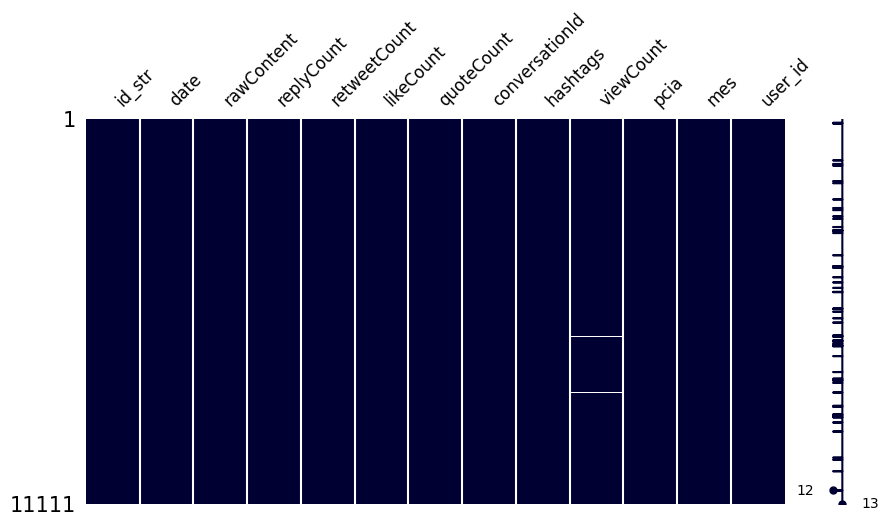

In [ ]:
msno.matrix(df, figsize=(10, 5), fontsize=12, color=(0, 0, 0.2))
plt.show()

La columna viewCount tiene 62 valores nulos, pero también existen dos columnas como "pcia" y "hashtags" cuyos valores son listas de strings y ambas también contienen listas vacias.

In [ ]:
pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe()

,id_str,replyCount,retweetCount,likeCount,quoteCount,conversationId,viewCount,mes,user_id
count,"11,111.00","11,111.00","11,111.00","11,111.00","11,111.00","11,111.00","11,049.00","11,111.00","11,111.00"
mean,"1,799,423,940,493,677,312.00",67.34,168.19,"2,097.65",69.60,"1,798,950,815,396,187,904.00","255,637.31",5.74,330.15
std,"37,019,124,389,829,968.00",707.61,"1,852.24","17,327.27",669.78,"39,866,244,603,820,832.00","2,692,943.67",3.35,249.61
min,"1,742,551,559,316,107,520.00",0.00,0.00,0.00,0.00,"587,795,061,225,697,280.00",1.00,1.00,0.00
25%,"1,767,217,400,238,250,240.00",0.00,0.00,0.00,0.00,"1,766,948,376,218,579,456.00",17.00,3.00,107.00
50%,"1,793,413,563,136,221,440.00",0.00,0.00,1.00,0.00,"1,793,194,634,803,298,816.00",56.00,5.00,298.00
75%,"1,827,749,729,410,683,136.00",1.00,0.00,3.00,0.00,"1,827,576,207,814,088,704.00",225.00,8.00,523.00
max,"1,870,045,511,706,620,160.00","49,463.00","130,263.00","878,342.00","31,877.00","1,870,029,828,369,330,432.00","154,426,838.00",12.00,"1,013.00"


Verificación de valores atípicos en variables numéricas:

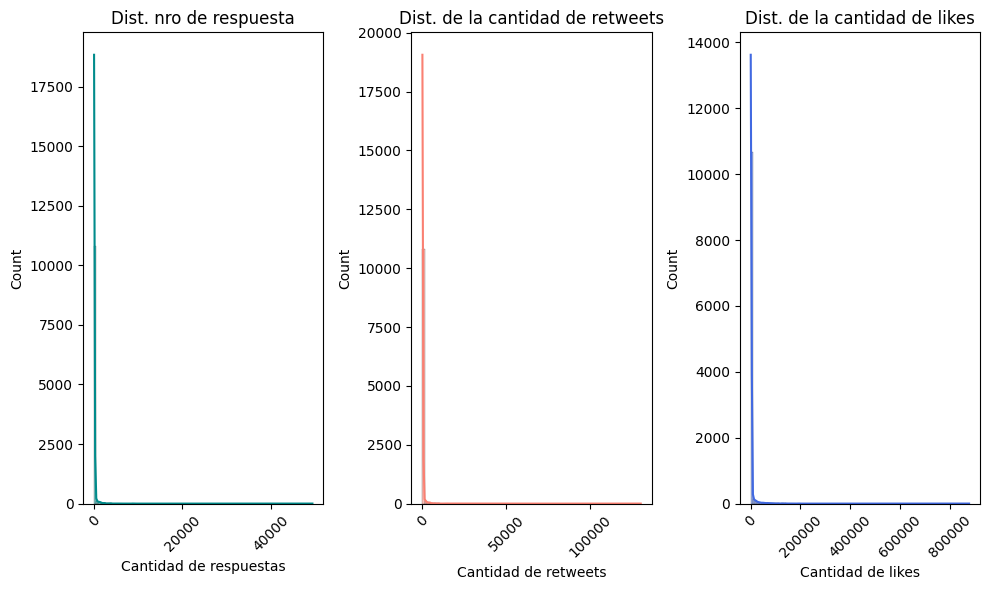

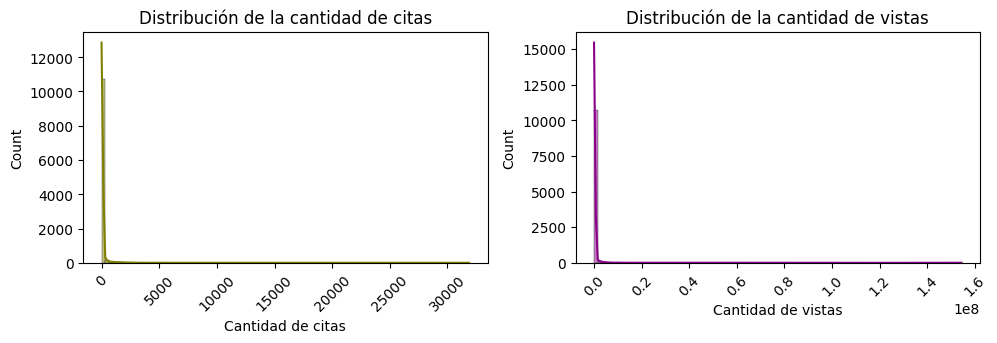

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.histplot(df['replyCount'], color='darkcyan', kde='True', bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de respuestas')
plt.title('Dist. nro de respuesta')

plt.subplot(1, 3, 2)
sns.histplot(df['retweetCount'], color='salmon',  kde='True', bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de retweets')
plt.title('Dist. de la cantidad de retweets')

plt.subplot(1, 3, 3)
sns.histplot(df['likeCount'], color='royalblue', kde='True', bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.histplot(df['quoteCount'], color='olive',  kde='True',bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de citas')
plt.title('Distribución de la cantidad de citas')

plt.subplot(2, 2, 2)
sns.histplot(df['viewCount'], color='darkmagenta',  kde='True',bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas')
plt.title('Distribución de la cantidad de vistas')

plt.tight_layout()
plt.show()



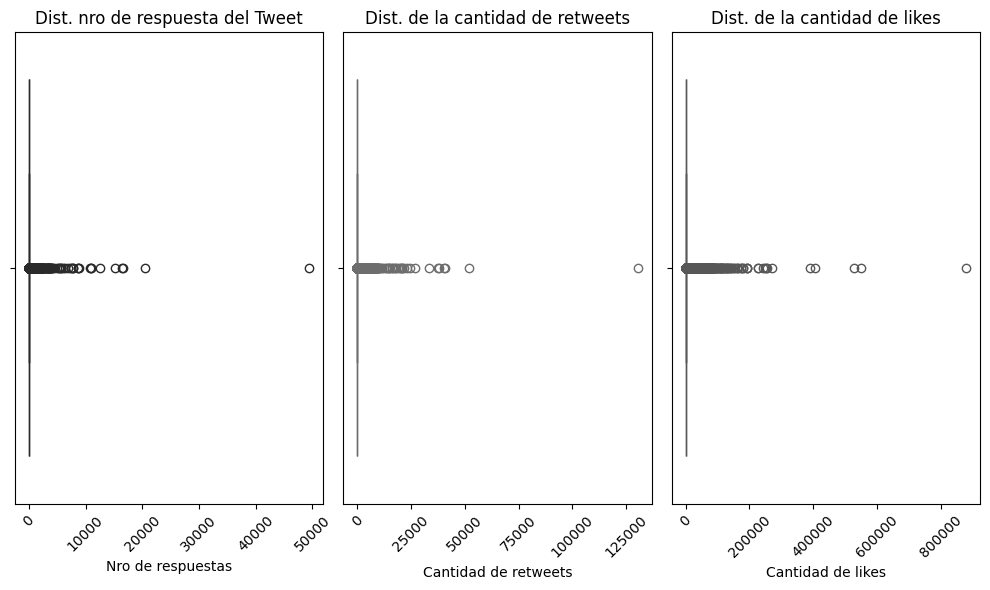

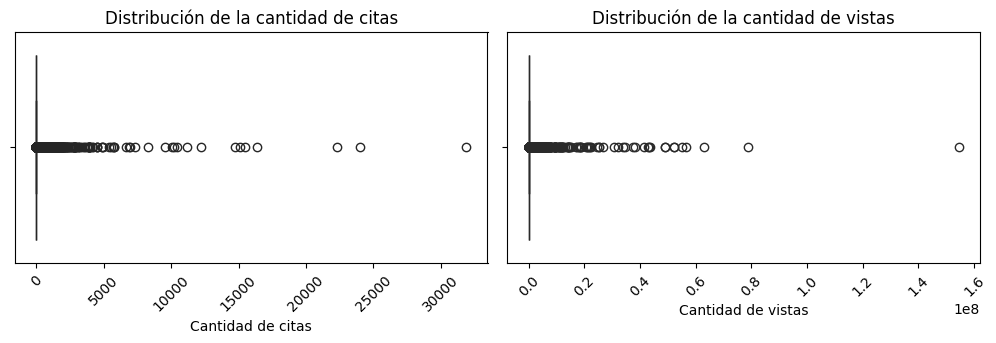

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x=df['replyCount'], color='darkcyan')
plt.xticks(rotation=45)
plt.xlabel('Nro de respuestas')
plt.title('Dist. nro de respuesta del Tweet')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['retweetCount'], color='salmon',)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de retweets')
plt.title('Dist. de la cantidad de retweets')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['likeCount'], color='royalblue')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.boxplot(x=df['quoteCount'], color='olive')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de citas')
plt.title('Distribución de la cantidad de citas')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['viewCount'], color='darkmagenta')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas')
plt.title('Distribución de la cantidad de vistas')

plt.tight_layout()
plt.show()

Se observan valores atípicos en variables como likeCount, retweetCount, replyCount, viewCount y quoteCount. Estas presentan distribuciones asimétricas con valores máximos muy alejados de la mediana. Existen valores mínimos en 0 y percentiles también muy bajos, lo cuál indica que la mayoría de los tweets tiene poca interacción. Pero también hay valores máximos muy altos pero que corresponden a tweets que son virales. Estos valores si bien son atípicos, son esperables en redes sociales.

Las variables id_str, conversationId, mes, user_id son numéricas pero representan identificadores (ya sea del mes, usuario, etc.) y no miden cantidades, por este motivo no son analizadas para buscar outliers.

Se analizará más adelante si estos valores atípicos están relacionados a la temática de nuestro interés.

#### Ejercicio 2.
* Elegir 5 columnas y describí su distribución o contenido. Por ejemplo: fecha del tweet (dias, o meses, u horarios), texto del tweet, provincia o ubicación geográfica, cantidad de likes, retweets o respuestas, etc.

*En este ejercicio deberán aplicar conocimientos de estadística sobre medidas resumen adecuadas al tipo de dato contenido en las variables.*

Variables elegidas:

**mes, pcia, viewCount, user_id, likeCount**

#### Análisis de variable: **mes**

In [ ]:
df['mes'].dtypes

dtype('int64')

In [ ]:
df['mes'].describe()

,mes
count,"11,111.00"
mean,5.74
std,3.35
min,1.00
25%,3.00
50%,5.00
75%,8.00
max,12.00


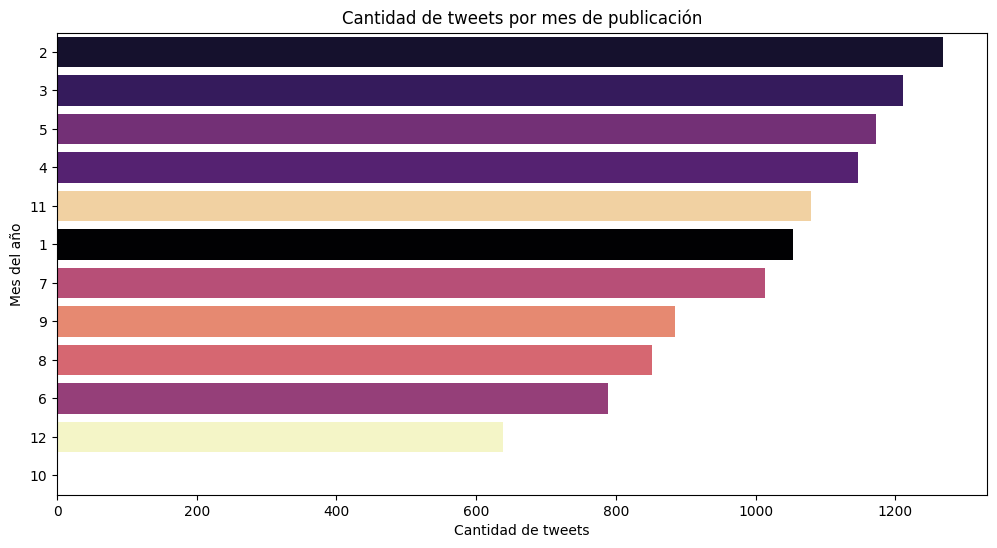

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='mes', order=df['mes'].value_counts().index, palette='magma', hue='mes', legend=False)
plt.xlabel('Cantidad de tweets')
plt.ylabel('Mes del año')
plt.title('Cantidad de tweets por mes de publicación')
plt.show()

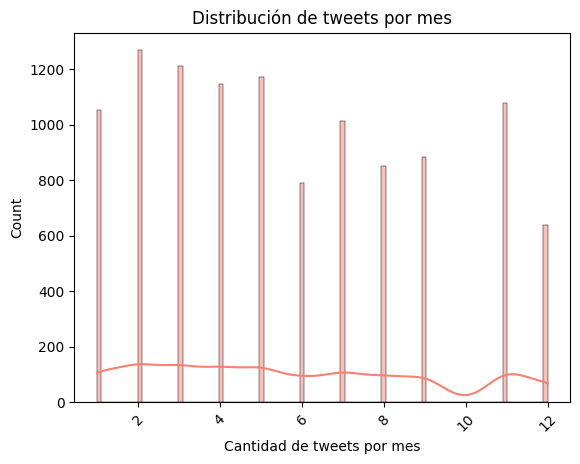

In [ ]:
sns.histplot(df['mes'], color='salmon',  kde='True',bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de tweets por mes')
plt.title('Distribución de tweets por mes')
plt.show()


In [ ]:
df[df['mes']==10] #Quiero ver qué datos hay relacionados a los únicos dos tweets de Octubre.

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id
9455,1851790518067302699,2024-10-31 00:57:18,haciendo brownies para la fiesta de la nena qu...,0,0,0.00,1,1851790518067302699,[],186.00,['buenos aires'],10,10
9476,1851997040735056149,2024-10-31 14:37:57,lo que me preocupa de la separacion de enzo fe...,91,1752,"38,669.00",96,1851997040735056149,[],"2,325,734.00",[],10,69


La distribución de la variable no es uniforme. Febrero, marzo, mayo, abril y noviembre son los meses con mayor cantidad de tweets publicados. En Octubre solo se publicaron dos tweets donde uno de ellos fue viral con 38.669 likes que no estan relaicionados al tema de estudio, la falta de tweets pulicados podría deberse a un error en la fuente de datos.

El pico en marzo puede estar relacionado a que el 4 de marzo se conmemora el Día Mundial de la Obesidad, para sensibilizar sobre el impacto de esta enfermedad y promover acciones para su prevención y tratamiento. A su vez, el pico en noviembre puede deberse a que el 12 de este mes se celebra el Día Mundial contra a Obesidad, esta fecha fue impulsada por la Organización Mundial de la Salud (OMS) y tiene como objetivo concientizar acerca de los riesgos que presenta esta condición. Además en el 14/11/2024 se publico un tweet sobre la salud pública en Estados Unidos que fue tendencia y fue citado 24027 cantidad de veces, esto podría estar provocando también el pico que vemos.

#### Análisis de variable: **pcia**

In [ ]:
df['pcia'].dtype

dtype('O')

Para este ejercicio se muestra la distribución de la variable pcia sin tratar los datos:

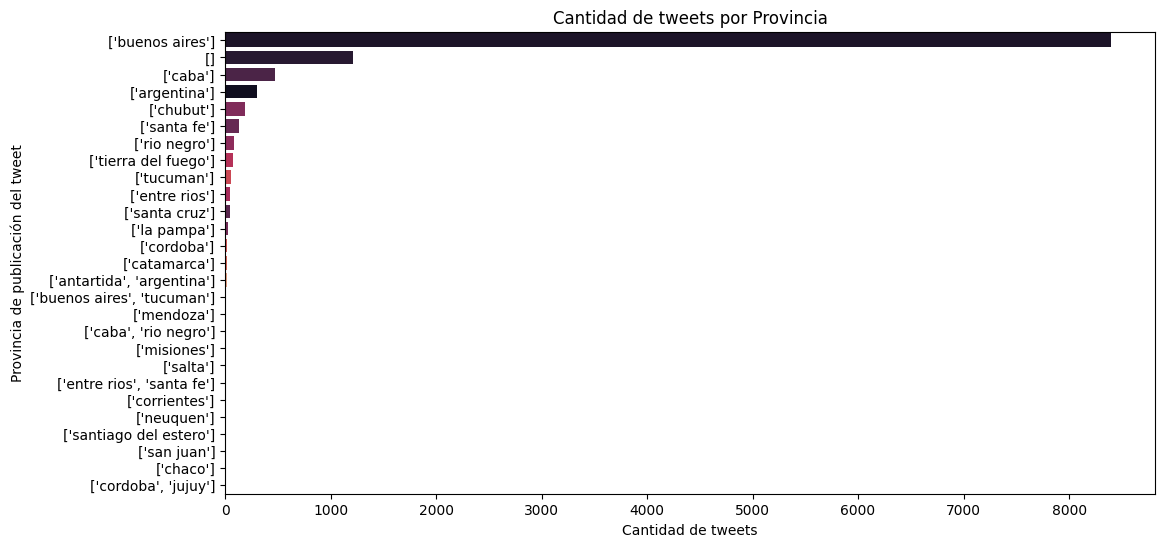

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='pcia', order=df['pcia'].value_counts().index, palette='rocket', hue='pcia', legend=False)
plt.xlabel('Cantidad de tweets')
plt.ylabel('Provincia de publicación del tweet')
plt.title('Cantidad de tweets por Provincia')
plt.show()

pcia es una variable categórica e indica la provincia desde la cual se publicó el tweet, se puede observar que la distribución está sesgada hacia pocas provincias o ubicaciones, donde la mayor cantidad de tweets publicados son desde la provincia de 'buenos aires'.

#### Análisis de variable: **viewCount**

In [ ]:
df['viewCount'].describe()

,viewCount
count,"11,049.00"
mean,"255,637.31"
std,"2,692,943.67"
min,1.00
25%,17.00
50%,56.00
75%,225.00
max,"154,426,838.00"


In [ ]:
df['viewCount'].isna().sum()

np.int64(62)

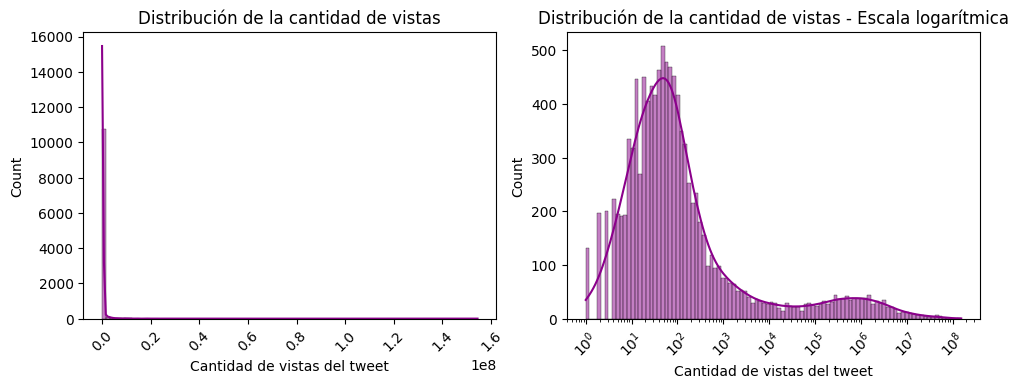

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['viewCount'], color='darkmagenta',  kde='True',bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas del tweet')
plt.title('Distribución de la cantidad de vistas')

plt.subplot(1, 2, 2)
sns.histplot(df['viewCount'], color='darkmagenta', kde=True, bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas del tweet')
plt.title('Distribución de la cantidad de vistas - Escala logarítmica')


plt.tight_layout()
plt.show()


In [ ]:
df['viewCount'].describe()

,viewCount
count,"11,049.00"
mean,"255,637.31"
std,"2,692,943.67"
min,1.00
25%,17.00
50%,56.00
75%,225.00
max,"154,426,838.00"


In [ ]:
#Se crea la siguiente función para calcular el límite superior que usaremos en
#cada variable a graficar para una mejor visualización.
def valores_atipicos_superior(datos):
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    atipicos_sup = q3 + (1.5 * iqr)

    return(atipicos_sup)

In [ ]:
lim_superior = valores_atipicos_superior(df['viewCount']) #Se calcula lím superior.
lim_superior

np.float64(537.0)

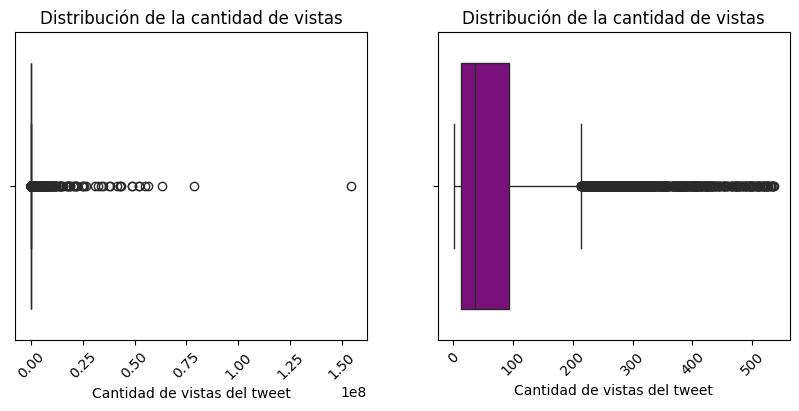

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['viewCount'], color='darkmagenta')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas del tweet')
plt.title('Distribución de la cantidad de vistas')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[df['viewCount']< lim_superior]['viewCount'], color='darkmagenta')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas del tweet')
plt.title('Distribución de la cantidad de vistas')
plt.show()

viewCount es una variable numérica con una distribución asimétrica y con presencia de valores atípicos. Tiene 62 valores faltantes. La media es de 255637,31 visualizaciones y está influenciada por los valores atípicos. La mediana es 56, esto significa que el 50% de los tweets tienen menos de 56 visualizaciones. El quartil Q3 es de 225, esto indica que el 75% de los tweets tiene 225 vistas o menos, confirma que la mayor cantidad de tweets del dataset tiene pocas visualizaciones. El valor máximo extremadamente alto se debe a tweets virales.

#### Análisis de variable: **user_id**

In [ ]:
df['user_id'].value_counts()

,count
user_id,
2,240
22,226
10,150
41,128
5,121
...,...
1009,1
1010,1
1011,1


Se selecciona para una mejor visualización los primeros 50 usuarios que mas postean:

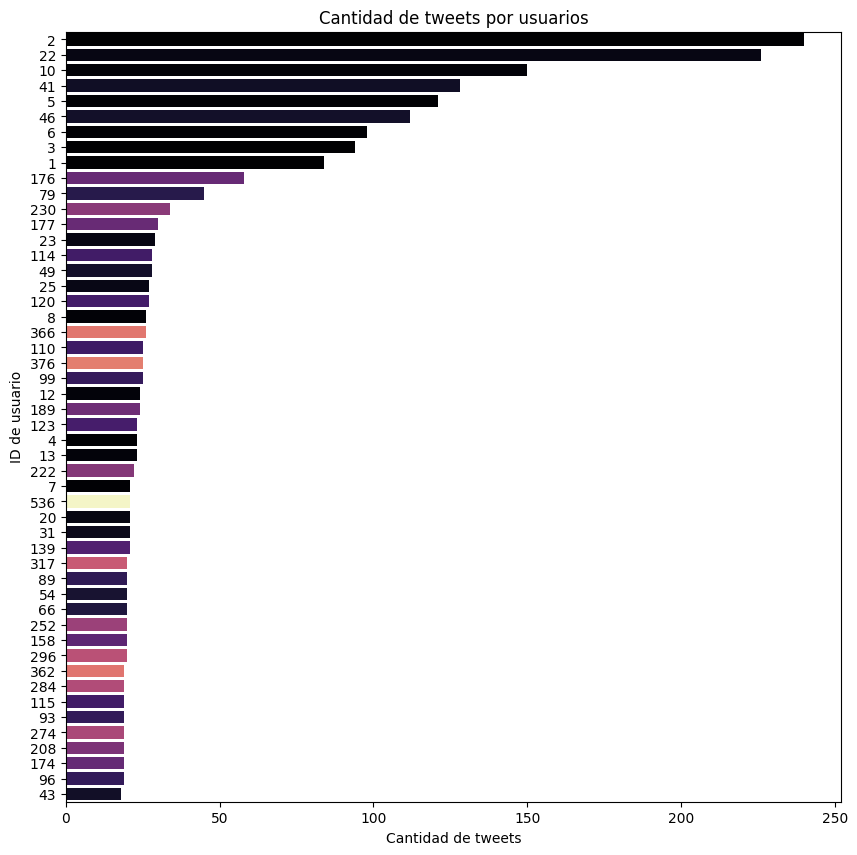

In [ ]:
plt.figure(figsize=(10, 10))
top_usuario = df['user_id'].value_counts().nlargest(50).index
sns.countplot(data=df[df['user_id'].isin(top_usuario)], y='user_id', order=top_usuario, palette= 'magma', hue='user_id', legend=False)
plt.title('Cantidad de tweets por usuarios')
plt.xlabel('Cantidad de tweets')
plt.ylabel('ID de usuario')
plt.show()

In [ ]:
df['user_id'].value_counts().describe()

,count
count,"1,014.00"
mean,10.96
std,14.33
min,1.00
25%,5.00
50%,11.00
75%,13.00
max,240.00


user_id es una variable numérica pero representa el identificador de usuario, no mide cantidades. La distribución de la variable es asimétrica. Basados en los datos estadísticos podemos decir que hay 1014 usuarios, el promedio de tweets por usuarios es de 10.96. La mediana es de 11 tweets, es decir que el 50% de los usuarios publico menos de 11 tweets. El quartil Q3 es 13, indicando que el 75% de los usuarios pubilicaron 13 tweets o menos. La mayoría de los usuarios publica en promedio 10 tweets y son muy pocos los usuarios que se mantienen muy activos (por ejemplo, el usuario 2 publico 240 tweets).

#### Análisis de variable: **likeCount**

In [ ]:
df['likeCount'].describe()

,likeCount
count,"11,111.00"
mean,"2,097.65"
std,"17,327.27"
min,0.00
25%,0.00
50%,1.00
75%,3.00
max,"878,342.00"


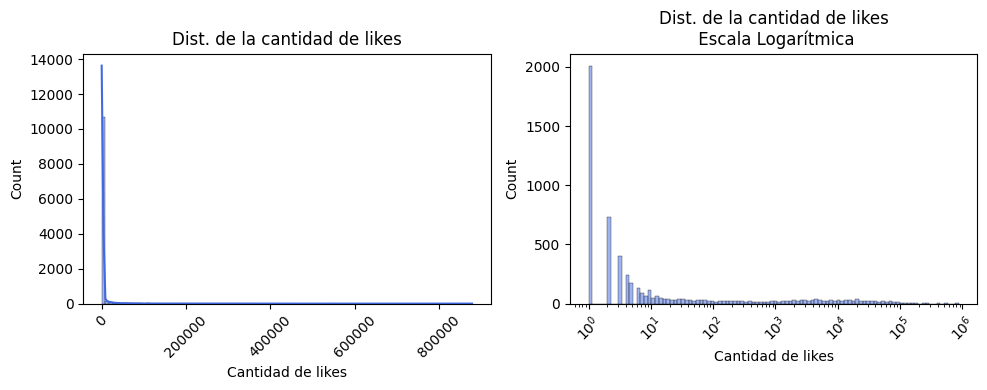

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['likeCount'], color='royalblue', kde='True', bins=100)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')

plt.subplot(1, 2, 2)
sns.histplot(df['likeCount'], color='royalblue', kde='True', bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes\n Escala Logarítmica')


plt.tight_layout()
plt.show()

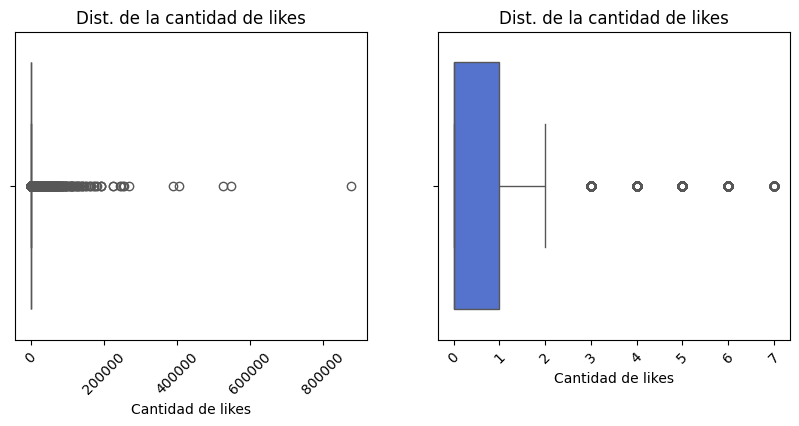

In [ ]:
lim_superior = valores_atipicos_superior(df['likeCount']) #Se calcula lím superior.

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['likeCount'], color='royalblue')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[df['likeCount']< lim_superior]['likeCount'], color='royalblue')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')
plt.show()

La variable likeCount es numérica y su distribución asimétrica y sesgada hacia la derecha. La mayoría de los tweets tienen pocos likes y muy pocos tweets tienen gran cantidad likes, indicando tweets virales. La mediana es 1, es decir que el 50% de los tweets tuvieron 1 like o menos. El 25% de los tweets no recibieron likes y el 75% recibieron 3 likes o menos. La media se ve influenciada por la presencia de tweets tendencias.

#### Análisis de la variable: rawContent

In [ ]:
# Número de comentarios duplicados
duplicated_comments = df['rawContent'].duplicated().sum()
print(f"Número de comentarios duplicados: {duplicated_comments}")

# Número de comentarios con una sola palabra
one_word_comments = df['rawContent'].str.split().apply(len) == 1
num_one_word_comments = one_word_comments.sum()
print(f"Número de comentarios con solo una palabra: {num_one_word_comments}")

# Número de comentarios con menos de 3 palabras y que contienen 'link_url'
less_than_3_words_and_link = (df['rawContent'].str.split().apply(len) < 3) & (df['rawContent'].str.contains('link_url', na=False))
num_less_than_3_words_and_link = less_than_3_words_and_link.sum()
print(f"Número de comentarios con menos de 3 palabras y un enlace: {num_less_than_3_words_and_link}")

Número de comentarios duplicados: 137
Número de comentarios con solo una palabra: 91
Número de comentarios con menos de 3 palabras y un enlace: 68


In [ ]:
df[df['rawContent'].duplicated()]['rawContent'].value_counts().sort_values(ascending=False).head(10)

,count
rawContent,
link_url,45
Cómo puede ser q una pediatra hablé así sabiendo q hay tantos niños y adolescentes con obesidad? Asco total ella y su grupo sinceramente está edision es lamentable como un programa permite tanta agresion?,19
obesa,6
obeso,6
"❗ ""La obesidad es una porquería"": internaron a ""El Gaucho"" de Cuestión de Peso\n\n👉🏻 Cuentan con úlceras en las piernas que pueden complicarse\n\n(💣 Para El Trece, el show debe continuar)\n\nlink_url link_url",4
Obeso,4
Sobrepeso,4
Obesa,3
"La obesidad es uno de los principales factores de riesgo de muchas enfermedades crónicas, que afectan la salud física y mental de niños, adolescentes y adultos.\n \nDescubrí los siguientes consejos básicos para prevenir o revertir el sobrepeso y la obesidad link_url",3


In [ ]:
df[df['rawContent'].duplicated()][['rawContent', 'user_id']].value_counts().sort_values(ascending=False).head(10)

rawContent                                                                                                                                                                                                                                             user_id
Cómo puede ser q una pediatra hablé así sabiendo q hay tantos niños y adolescentes con obesidad? Asco total ella y su grupo      sinceramente está edision es lamentable como un programa permite tanta agresion?                                      79         19
❗ "La obesidad es una porquería": internaron a "El Gaucho" de Cuestión de Peso\n\n👉🏻 Cuentan con úlceras en las piernas que pueden complicarse\n\n(💣 Para El Trece, el show debe continuar)\n\nlink_url link_url                                       471         4
link_url                                                                                                                                                                                                                                               430         3
                                                                                                                                                                                                                                                       90          2
                                                                                                                                                                                                                                                       449         2
Anotá: Argentina tiene el índice más alto de obesidad infantil de Sudamérica. La principal causa es el consumo de alimentos procesados con altos niveles de azúcar, grasas y sal. Y el alto acceso y asequibilidad a estos productos poco saludables.  605         2
"La obesidad es una pandemia de muerte lenta y aún tardamos en reaccionar" link_url                                                                                                                                                                    275         1
? link_url                                                                                                                                                                                                                                             325         1
. Expande Horizontes: su fármaco para la #obesidad apunta a enfermedades #hepáticas y #renales\n\n#Amgen planea probar su medicamento para la obesidad #MariTide.\n\n#Salud #Negocios #Gobierno #Innovación\nlink_url                                  177         1
Cerra el orto obesa                                                                                                                                                                                                                                    185         1
Name: count, dtype: int64

In [ ]:
df[one_word_comments].rawContent.value_counts().sort_values(ascending=False).head(10)

,count
rawContent,
link_url,46
obesa,7
obeso,7
Obeso,5
Sobrepeso,5
Obesa,4
obesidad,2
Obeso?,2
Obesa?,2


Entendemos que link_url simboliza un link que fue reemplazado por ese string. Encontramos algunos comentarios duplicados, entre ellos link_url que deberá ser filtrado y algunos que consideramos que son muy probables como 'obeso'. Aparecen un par más que al ser del mismo usuario se trata de que el usuario posteo varias veces lo mismo o es un error en la recolección de datos.

### **Visualización de datos**

#### Ejercicio 3
Tendencias de tweets en el tiempo, ¿Qué observamos en nuestro dataset?

* a. Se debe graficar la cantidad de tweets de acuerdo a la fecha (puede ser por mes, día, horario, semana). Al menos dos gráficos.
* b. Interpretar la visualización elegida. ¿Se observan picos o caídas en los gráficos? ¿Qué podría inferir de acuerdo a lo observado?
* c. Respecto a la distribución espacial, se deberá graficar la distribución de tweets por provincia. Elegir una medida adecuada y justificar su elección. (frecuencias absolutas, relativas, quantiles de distribución , etc)
* d. Realizar interpretación del gráfico de distribución espacial. Generar inferencias de acuerdo a lo observado.

#### Ejercicio 4

* a. Retomando el ejercicio 1.d. Cómo podrán observar en la base detectarán que la cantidad de likes, retweets y respuestas suele variar, observandose algunos outliers. ¿Pueden identificarlos? ¿Qué medidas podrían tomar al respecto de acuerdo a la descripción del problema? justificar.
* b. Existen hashtags con mayor o menor frecuencia de uso en esta muestra de datos. ¿Puede reconocerlos? Generar una visualización para tal fin que brinde información pero también sea visualmente amigable.


#### Ejercicio 3


#### Desarrollo puntos a y b:

In [ ]:
df['date'] = pd.to_datetime(df['date'])

#### Tweets por hora del día:

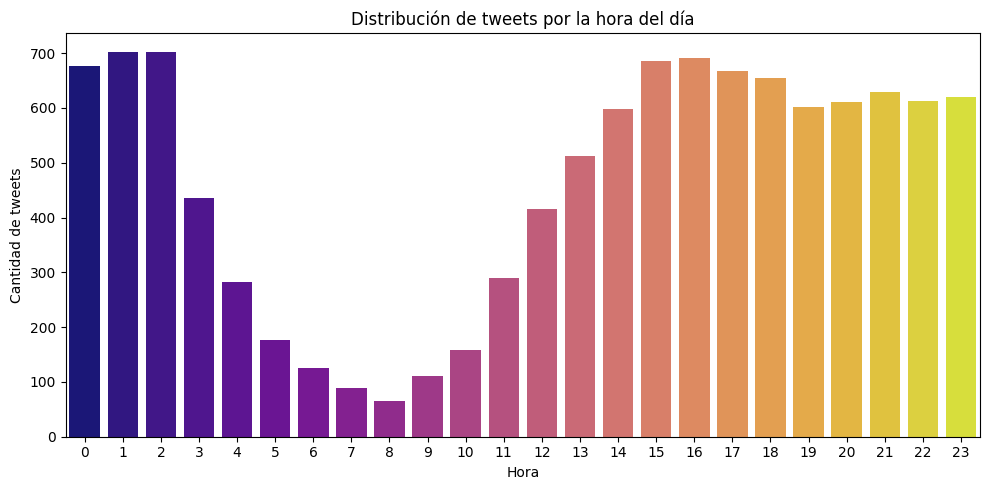

In [ ]:
df['hora'] = df['date'].dt.hour
plt.figure(figsize=(10, 5))
sns.countplot(data= df, x='hora', palette='plasma', hue='hora', legend=False)
plt.xlabel('Hora')
plt.ylabel('Cantidad de tweets')
plt.title('Distribución de tweets por la hora del día')
plt.tight_layout()
plt.show()

La distribución de tweets por hora del día nos permite ver que hay dos franjas horarias de mayor actividad, entre las 3 y 5 pm, y durante la madrugada, entre la 1 y 2 am.


#### Tweets por día de la semana

In [ ]:
dias =  {1: 'Lunes', 2: 'Martes', 3: 'Miércoles', 4: 'Jueves', 5: 'Viernes', 6: 'Sábado', 7: 'Domingo'}

df['dia'] = df['date'].dt.isocalendar().day
df['dia'] = df['dia'].map(dias)

In [ ]:
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['dia'] = pd.Categorical(df['dia'], categories=orden_dias, ordered=True)

/tmp/ipython-input-41-3335654245.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cant_tweets = df.groupby('dia').size().reset_index(name='cantidad')


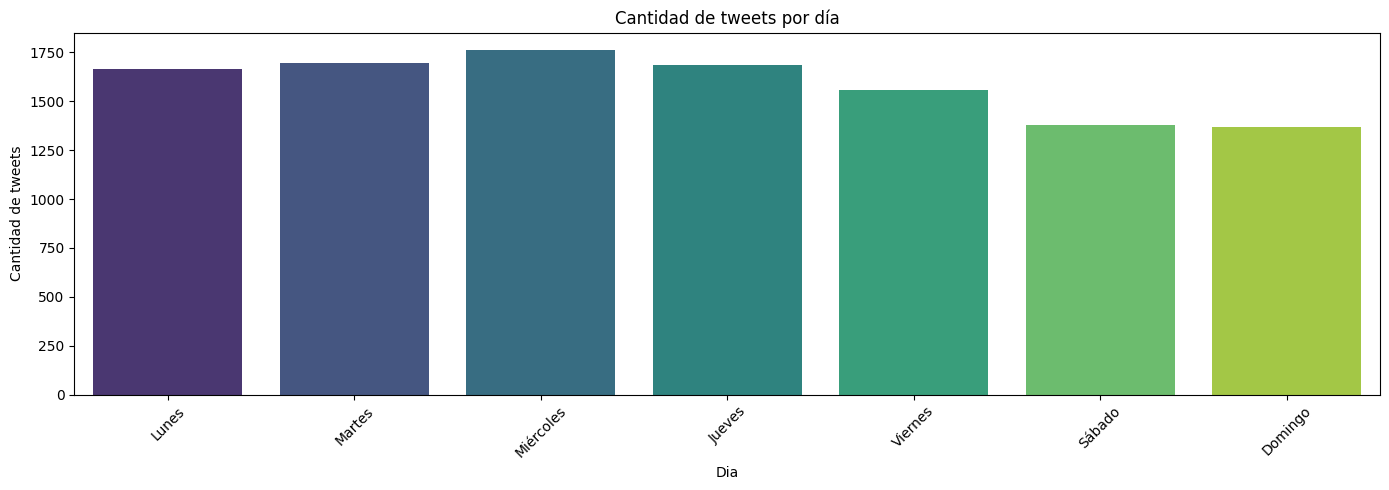

In [ ]:
cant_tweets = df.groupby('dia').size().reset_index(name='cantidad')

plt.figure(figsize=(14, 5))
sns.barplot(data=cant_tweets, x='dia', y='cantidad', palette='viridis', hue= 'dia', legend=False)
plt.xlabel('Dia')
plt.ylabel('Cantidad de tweets')
plt.title('Cantidad de tweets por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Tweets por semanas:

In [ ]:
df['semana'] = df['date'].dt.isocalendar().week
df['nombre_mes'] = df['date'].dt.month_name()
mes_predominante = df.groupby('semana')['nombre_mes'].agg(lambda x: x.mode().iloc[0])

cant_tweets = df['semana'].value_counts().sort_index()
etiqueta = [f"Sem {semana} - {mes_predominante.loc[semana]}" for semana in cant_tweets.index]

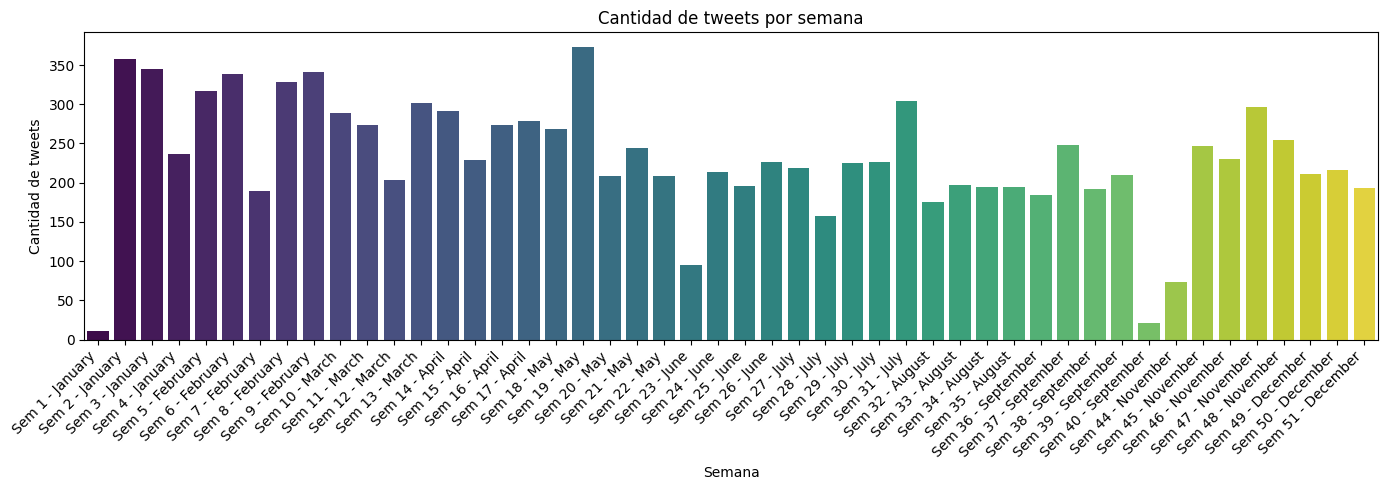

In [ ]:
plt.figure(figsize=(14, 5))
sns.barplot(x=cant_tweets.index, y=cant_tweets.values, palette='viridis', hue=cant_tweets.index, legend=False )
plt.xticks(ticks=range(len(etiqueta)), labels=etiqueta, rotation=45, ha='right')
plt.xlabel('Semana')
plt.ylabel('Cantidad de tweets')
plt.title('Cantidad de tweets por semana')
plt.tight_layout()
plt.show()


La semana 19 (mayo) es donde estuvo el pico mas alto de tweets publicados, esto puede deberse a algún tema viral o evento que provoco este aumento en posteos, por ejemplo, el inicio del programa Cuestión de Peso lo cuál podría haber llevado a debates sobre el tema.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_tweets_and_metric(
    dataframe,
    date_col: str,
    period: str,
    metric: str = None,
    bar_width: float = 0.8
):
    """
    Grafica la cantidad de tweets y opcionalmente la evolución de una métrica.
    Las barras usan un gradiente posicional y la línea se dibuja por encima.

    Args:
        dataframe (pd.DataFrame): El DataFrame con los datos.
        date_col (str): Nombre de la columna con fechas.
        period (str): Periodo para agrupar ('D', 'W', 'M', etc.).
        metric (str, optional): Columna de métrica a graficar (ej: 'retweetCount').
        bar_width (float): Ancho de las barras de la cuenta de tweets.
    """
    df_temp = dataframe.copy()
    df_temp[date_col] = pd.to_datetime(df_temp[date_col])
    df_temp = df_temp.set_index(date_col)

    tweet_counts = df_temp.resample(period).size()
    if metric:
        metric_sum = df_temp[metric].resample(period).sum()

    fig, ax1 = plt.subplots(figsize=(15, 7))
    title = f"Cantidad de Tweets ({period})"
    if metric:
        title += f" y suma de '{metric}'"
    ax1.set_title(title, fontsize=16)

    # Eje izquierdo: Línea en color negro
    ax1.plot(
        tweet_counts.index,
        tweet_counts.values,
        linewidth=2.5,
        label='Cantidad de Tweets',
        color='black'
    )
    ax1.set_ylabel('Cantidad de Tweets', fontsize=12, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_ylim(bottom=0)

    # Eje derecho: Barras con gradiente viridis
    if metric:
        ax2 = ax1.twinx()
        cmap = plt.get_cmap('viridis')
        bar_colors = cmap(np.linspace(0, 1, len(metric_sum)))

        ax2.bar(
            metric_sum.index,
            metric_sum.values,
            color=bar_colors,
            width=bar_width,
            label=f"Suma de {metric}"
        )
        axis_color = 'dimgray'
        ax2.set_ylabel(f'Suma de {metric}', fontsize=12, color=axis_color)
        ax2.tick_params(axis='y', labelcolor=axis_color)
        ax2.set_ylim(bottom=0)

        # Ajuste para que la línea (ax1) se dibuje sobre las barras (ax2)
        ax1.set_zorder(ax2.get_zorder() + 1)
        ax1.patch.set_visible(False)


    # Leyenda combinada
    lines, labels = [], []
    axes_to_use = (ax1, ax2) if metric else (ax1,)
    for ax in axes_to_use:
        line, lab = ax.get_legend_handles_labels()
        lines.extend(line)
        labels.extend(lab)
    fig.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.9, 0.9))

    plt.xlabel('Fecha')
    plt.grid(False)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

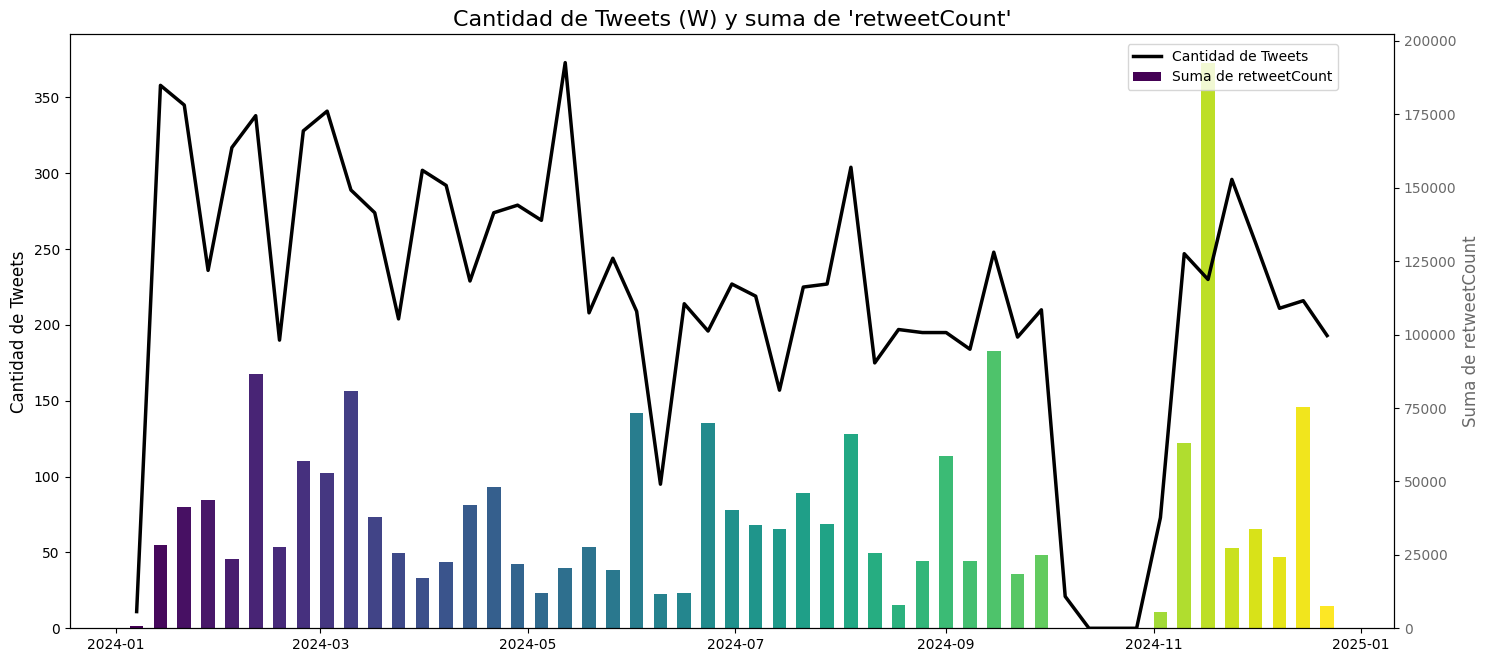

In [ ]:
plot_tweets_and_metric(
    df,
    date_col='date',
    period='W',
    metric='retweetCount',
    bar_width=4.0
)

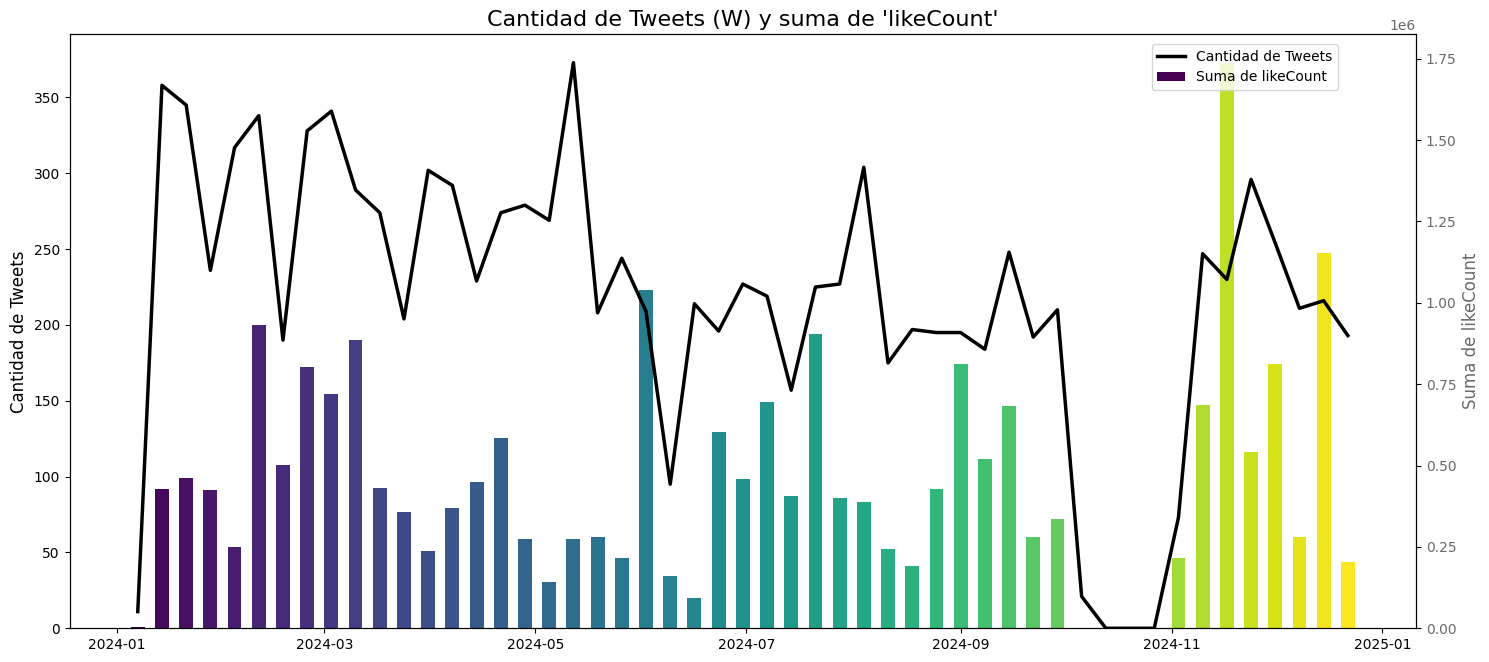

In [ ]:
plot_tweets_and_metric(
    df,
    date_col='date',
    period='W',
    metric='likeCount',
    bar_width=4.0
)

In [ ]:
start_date = "14/11/2024"
end_date = "21/11/2024"

df['date'] = pd.to_datetime(df['date'])
start_dt = pd.to_datetime(start_date, format='%d/%m/%Y')
end_dt = pd.to_datetime(end_date, format='%d/%m/%Y')

df_filtered = df[(df['date'] >= start_dt) & (df['date'] <= end_dt)].copy()

df_ordered = df_filtered.sort_values(by=['retweetCount', 'likeCount'], ascending=[False, False])

pd.set_option('display.max_colwidth', None)

df_ordered[['rawContent', 'retweetCount', 'likeCount']].head(5)

,rawContent,retweetCount,likeCount
10004,"I am thrilled to announce Robert F. Kennedy Jr. as The United States Secretary of Health and Human Services (HHS). For too long, Americans have been crushed by the industrial food complex and drug companies who have engaged in deception, misinformation, and disinformation when it comes to Public Health. The Safety and Health of all Americans is the most important role of any Administration, and HHS will play a big role in helping ensure that everybody will be protected from harmful chemicals, pollutants, pesticides, pharmaceutical products, and food additives that have contributed to the overwhelming Health Crisis in this Country. Mr. Kennedy will restore these Agencies to the traditions of Gold Standard Scientific Research, and beacons of Transparency, to end the Chronic Disease epidemic, and to Make America Great and Healthy Again!",130263,"878,342.00"
9888,"""Cuando una sociedad pierde su brújula moral, se derrumba desde dentro"". – G.K. Chesterton\n\nUn hilo que expone la decadencia de Occidente🧵\n\n1. La celebración de la obesidad link_url",7610,"65,926.00"
9934,los chabones cuando pesas mas de 50 kilos: che puede q seas un poco obesa mórbida no?,6021,"97,604.00"
10000,"creo firmemente q donde hubo conexión y no hubo relación, hay segunda parte link_url",5828,"92,079.00"
10207,link_url,4473,"55,153.00"


El pico de retweets y likes de la 3ra semana de noviembre está dado por uno en particular que ya hemos mencionado y se trata de un anuncio sobre un nuevo secretario de salud en Estados Unidos. Consideramos que no se trata de un posteo relevante para abordar el tema que nos interesa.

In [ ]:
start_date = "01/06/2024"
end_date = "07/06/2024"

start_dt = pd.to_datetime(start_date, format='%d/%m/%Y')
end_dt = pd.to_datetime(end_date, format='%d/%m/%Y')

df_filtered = df[(df['date'] >= start_dt) & (df['date'] <= end_dt)].copy()

df_ordered = df_filtered.sort_values(by=['likeCount'], ascending=[False])

df_ordered[['rawContent', 'likeCount']].head(5)

,rawContent,likeCount
5968,"a thread of how marilyn monroe actually looked in real life, in honor of her 98th birthday link_url","547,991.00"
5908,mi mama dps de hablar un ratito por telefono: link_url,"124,473.00"
5852,no aguanto mas ver como todas estan anorexicas menos yo asi nomas se los digo,"12,004.00"
5875,La protagonista analizando la casa 🫶🏻 sos INCREÍBLE FURIA 🏹♥️,"4,756.00"
5944,Jugadores que erraron el gol de su vida\nEjemplo link_url,"1,454.00"


En la primera semana de junio encontramos encontramos un pico de likes que surge a partir de un posteo en inglés sobre Marilyn Monroe. El posteo en cuestión es el siguiente https://x.com/allurequinn/status/1796947616762388730, y nuevamente poco tiene que ver con la temática en cuestión.

Luego, de los 5 primeros notamos que solo uno tiene directa relación con nuestro objeto de interés. Esto nos dice que, por un lado, nuestro dataset contiene algo de ruido que tendremos que decidir cómo abordar. Por otro lado, si decidimos valorar la importancia de los tweets de acuerdo a sus métricas de interacción tendremos que limpiar previamente aquellos que no están relacionados; ya que distorsionarán cualquier análisis.

In [ ]:
pd.set_option('display.max_colwidth', 50)

#### Desarrollo puntos c y d:

In [ ]:
print(type(df['pcia'].iloc[0]))  # Verificamos el tipo de dato de lo que parece ser una lista en pcia.

<class 'str'>


Como se trata de un string en forma de lista, se debera primero pasar a lista:

In [ ]:
import ast
df['pcia1'] = df['pcia'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
print(type(df['pcia1'].iloc[0]))

<class 'list'>


In [ ]:
df['provincia'] = df['pcia1'].apply(lambda x: x[0] if (isinstance(x, list)) and (len(x) > 0) else 'SE')

In [ ]:
df.provincia.unique()

array(['argentina', 'buenos aires', 'SE', 'entre rios', 'misiones',
       'caba', 'santa cruz', 'santa fe', 'la pampa', 'chubut',
       'rio negro', 'mendoza', 'tierra del fuego', 'tucuman', 'cordoba',
       'catamarca', 'corrientes', 'salta', 'neuquen', 'antartida',
       'santiago del estero', 'san juan', 'chaco'], dtype=object)

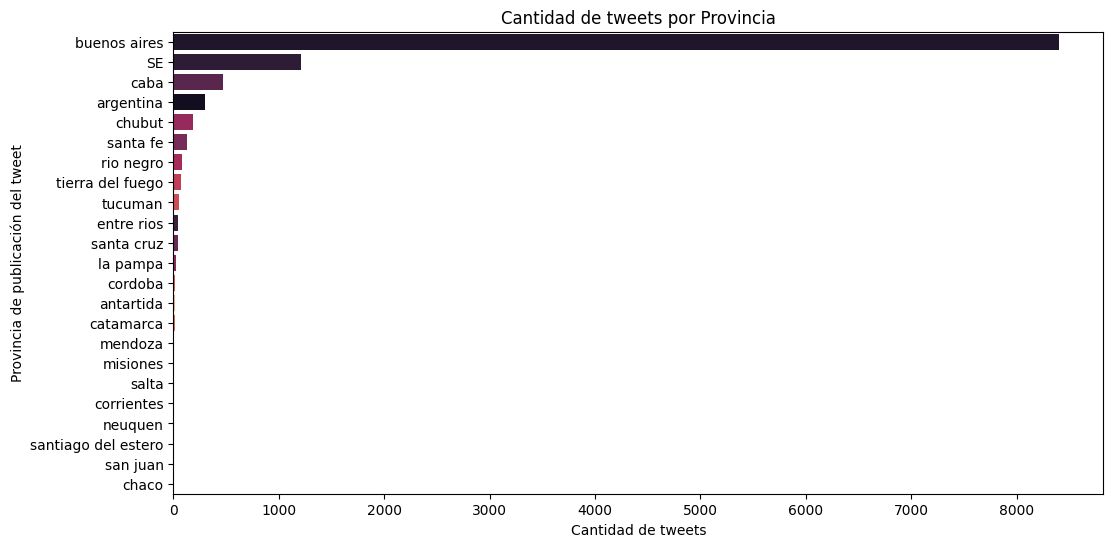

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='provincia', order=df['provincia'].value_counts().index, palette='rocket', hue='provincia', legend=False)
plt.xlabel('Cantidad de tweets')
plt.ylabel('Provincia de publicación del tweet')
plt.title('Cantidad de tweets por Provincia')
plt.show()

Elegimos frecuencias absolutas porque queremos observar la cantidad real de tweets publicados desde cada provincia.

#### Ejercicio 4

##### Desarrollo punto a: Outliers

Como se comento anteriormente el dataset tiene valores atípicos en variables como likeCount, retweetCount, replyCount, viewCount y quoteCount. Existen valores mínimos en 0 y también hay valores máximos muy altos pero que corresponden a tweets que son virales. Como sabemos, estos valores si bien son atípicos, son esperables en redes sociales. A continuación realizaremos un análisis para saber de qué se trata cada tweet y poder determinar si son outliers para el caso de estudio.

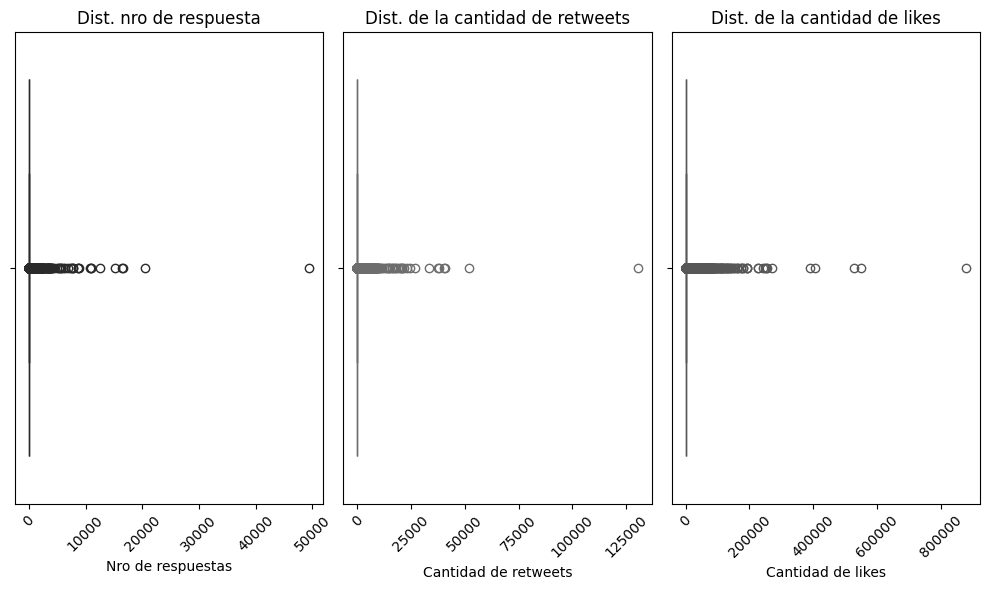

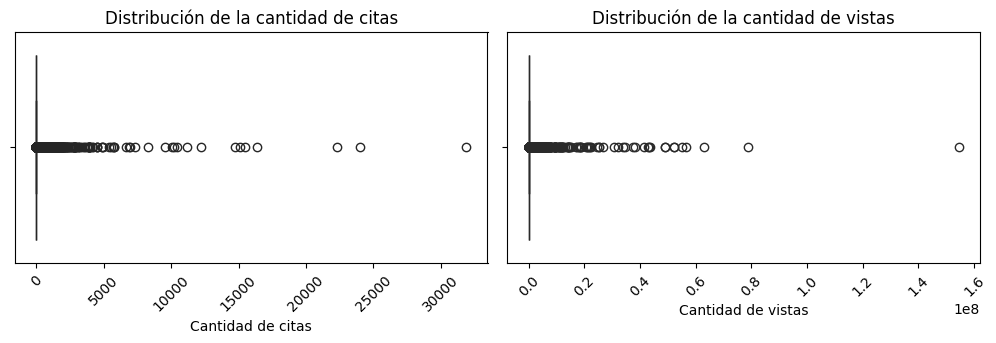

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x=df['replyCount'], color='darkcyan')
plt.xticks(rotation=45)
plt.xlabel('Nro de respuestas')
plt.title('Dist. nro de respuesta')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['retweetCount'], color='salmon',)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de retweets')
plt.title('Dist. de la cantidad de retweets')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['likeCount'], color='royalblue')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.boxplot(x=df['quoteCount'], color='olive')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de citas')
plt.title('Distribución de la cantidad de citas')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['viewCount'], color='darkmagenta')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas')
plt.title('Distribución de la cantidad de vistas')

plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,id_str,date,replyCount,retweetCount,likeCount,quoteCount,conversationId,viewCount,mes,user_id,hora,semana
count,"11,111.00",11111,"11,111.00","11,111.00","11,111.00","11,111.00","11,111.00","11,049.00","11,111.00","11,111.00","11,111.00","11,111.00"
mean,"1,799,423,940,493,677,312.00",2024-06-08 12:51:13.252452608,67.34,168.19,"2,097.65",69.60,"1,798,950,815,396,187,904.00","255,637.31",5.74,330.15,12.80,23.31
min,"1,742,551,559,316,107,520.00",2024-01-03 14:20:41,0.00,0.00,0.00,0.00,"587,795,061,225,697,280.00",1.00,1.00,0.00,0.00,1.00
25%,"1,767,217,400,238,250,240.00",2024-03-11 15:53:55.500000,0.00,0.00,0.00,0.00,"1,766,948,376,218,579,456.00",17.00,3.00,107.00,4.00,11.00
50%,"1,793,413,563,136,221,440.00",2024-05-22 22:48:08,0.00,0.00,1.00,0.00,"1,793,194,634,803,298,816.00",56.00,5.00,298.00,15.00,21.00
75%,"1,827,749,729,410,683,136.00",2024-08-25 16:47:47.500000,1.00,0.00,3.00,0.00,"1,827,576,207,814,088,704.00",225.00,8.00,523.00,19.00,34.00
max,"1,870,045,511,706,620,160.00",2024-12-20 09:56:08,"49,463.00","130,263.00","878,342.00","31,877.00","1,870,029,828,369,330,432.00","154,426,838.00",12.00,"1,013.00",23.00,51.00
std,"37,019,124,389,829,968.00",NaN,707.61,"1,852.24","17,327.27",669.78,"39,866,244,603,820,832.00","2,692,943.67",3.35,249.61,7.55,14.60


In [ ]:
pd.set_option('display.max_colwidth', None) #Esta línea nos permite leer todo el el contenido de las columnas.

In [ ]:
# Se analiza el tweet con máximo numero de respuestas:
df[df['replyCount']== 49463]['rawContent']

,rawContent
10004,"I am thrilled to announce Robert F. Kennedy Jr. as The United States Secretary of Health and Human Services (HHS). For too long, Americans have been crushed by the industrial food complex and drug companies who have engaged in deception, misinformation, and disinformation when it comes to Public Health. The Safety and Health of all Americans is the most important role of any Administration, and HHS will play a big role in helping ensure that everybody will be protected from harmful chemicals, pollutants, pesticides, pharmaceutical products, and food additives that have contributed to the overwhelming Health Crisis in this Country. Mr. Kennedy will restore these Agencies to the traditions of Gold Standard Scientific Research, and beacons of Transparency, to end the Chronic Disease epidemic, and to Make America Great and Healthy Again!"


In [ ]:
df[df['replyCount']< 49463]['replyCount'].describe() #Verificamos cuál es el número máximo siguiente de respuestas.

,replyCount
count,"11,110.00"
mean,62.89
std,530.19
min,0.00
25%,0.00
50%,0.00
75%,1.00
max,"20,464.00"


In [ ]:
df[df['replyCount']==20464]['rawContent']

,rawContent
8028,"Alberto Fernández no fue un buen presidente. Tampoco lo fueron Mauricio Macri o Fernando De La Rúa, sólo por mencionar a los que desempeñaron su mandato en lo que va del siglo XXI. Seguramente la lista sería más larga si extendiéramos la cronología.\n\nPero las imágenes que vimos ayer por la noche transmitidas por los medios de comunicación en virtual cadena nacional, en lo que constituye una verdadera revictimización de la denunciante, SON OTRA COSA. \n\nLas fotos de la Sra. Fabiola Yañez con hematomas en su cuerpo y rostro junto a los chats publicados que revelan el diálogo entre ella y el ex Presidente, no sólo muestran la golpiza recibida, sino que delatan los aspectos más sórdidos y oscuros de la condición humana. Permiten comprobar, una vez más y dramáticamente, la situación de la mujer en cualquier relación, se desarrolle ésta en un palacio o en una choza.\n\nLa misoginia, el machismo y la hipocresía, pilares en los que se asienta la violencia verbal o física contra la mujer, no tienen bandera partidaria y atraviesan a la sociedad en todos sus estamentos.\n\nEn lo personal y como mujer que ha sido objeto (y lo sigue siendo) de las peores violencias verbales y políticas, hasta la máxima experiencia de violencia física, como fue el intento de asesinato del 1 de septiembre del 2022, expreso mi solidaridad con todas las mujeres víctimas de cualquier tipo de violencia, sin olvidar las palabras que Francisco me dijo al día siguiente de aquel hecho: “toda violencia física siempre es precedida de violencia verbal”."


In [ ]:
# Se analiza el tweet con máximo numero de retweet:
df[df['retweetCount']==130263]['rawContent']

,rawContent
10004,"I am thrilled to announce Robert F. Kennedy Jr. as The United States Secretary of Health and Human Services (HHS). For too long, Americans have been crushed by the industrial food complex and drug companies who have engaged in deception, misinformation, and disinformation when it comes to Public Health. The Safety and Health of all Americans is the most important role of any Administration, and HHS will play a big role in helping ensure that everybody will be protected from harmful chemicals, pollutants, pesticides, pharmaceutical products, and food additives that have contributed to the overwhelming Health Crisis in this Country. Mr. Kennedy will restore these Agencies to the traditions of Gold Standard Scientific Research, and beacons of Transparency, to end the Chronic Disease epidemic, and to Make America Great and Healthy Again!"


In [ ]:
df[df['retweetCount']<130263]['retweetCount'].describe() #Verificamos cuál es el máximo siguiente de cantidad de retweets.

,retweetCount
count,"11,110.00"
mean,156.48
std,"1,381.11"
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,"51,907.00"


In [ ]:
df[df['retweetCount']== 51907]['rawContent']

,rawContent
8898,i can’t comprehend that such words became a normal thing for people to read and scroll past


In [ ]:
# Se analiza el tweet con máximo numero de likes:
df[df['likeCount']==878342]['rawContent']

,rawContent
10004,"I am thrilled to announce Robert F. Kennedy Jr. as The United States Secretary of Health and Human Services (HHS). For too long, Americans have been crushed by the industrial food complex and drug companies who have engaged in deception, misinformation, and disinformation when it comes to Public Health. The Safety and Health of all Americans is the most important role of any Administration, and HHS will play a big role in helping ensure that everybody will be protected from harmful chemicals, pollutants, pesticides, pharmaceutical products, and food additives that have contributed to the overwhelming Health Crisis in this Country. Mr. Kennedy will restore these Agencies to the traditions of Gold Standard Scientific Research, and beacons of Transparency, to end the Chronic Disease epidemic, and to Make America Great and Healthy Again!"


In [ ]:
df[df['likeCount']<878342]['likeCount'].describe() #Verificamos cuál es el valor máximo siguiente de likes.

,likeCount
count,"11,110.00"
mean,"2,018.78"
std,"15,203.27"
min,0.00
25%,0.00
50%,1.00
75%,3.00
max,"547,991.00"


In [ ]:
df[df['likeCount']==547991]['rawContent']

,rawContent
5968,"a thread of how marilyn monroe actually looked in real life, in honor of her 98th birthday link_url"


In [ ]:
# Se analiza el tweet con máximo numero de visualizaciones:
df[df['viewCount']== 154426838]['rawContent']

,rawContent
10004,"I am thrilled to announce Robert F. Kennedy Jr. as The United States Secretary of Health and Human Services (HHS). For too long, Americans have been crushed by the industrial food complex and drug companies who have engaged in deception, misinformation, and disinformation when it comes to Public Health. The Safety and Health of all Americans is the most important role of any Administration, and HHS will play a big role in helping ensure that everybody will be protected from harmful chemicals, pollutants, pesticides, pharmaceutical products, and food additives that have contributed to the overwhelming Health Crisis in this Country. Mr. Kennedy will restore these Agencies to the traditions of Gold Standard Scientific Research, and beacons of Transparency, to end the Chronic Disease epidemic, and to Make America Great and Healthy Again!"


In [ ]:
df[df['viewCount']<154426838]['viewCount'].describe()

,viewCount
count,"11,048.00"
mean,"241,682.64"
std,"2,258,496.01"
min,1.00
25%,17.00
50%,56.00
75%,225.00
max,"78,889,850.00"


In [ ]:
df[df['viewCount']==78889850]

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,hora,dia,semana,nombre_mes,pcia1,provincia
1654,1756528736785076338,2024-02-11 04:01:00,"News stand, NYC, 1930 link_url",1419,4545,"39,504.00",1391,1756528736785076338,[],"78,889,850.00",[],2,444,4,Domingo,6,February,[],SE


Para los valores máximos de las variables replayCount, retweetCount, likeCount y viewCount, el contenido del tweet hace referencia a la salud pública en Estados Unidos, esto nos hace pensar que se trata de un valor atípico ya que sale del alcance del lugar de estudio del proyecto que es Argentina.

También analizamos los tweets con los siguientes valores máximos para cada variable y también indicarían que son valores atípicos también.

In [ ]:
df[df['quoteCount']==31877]

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,hora,dia,semana,nombre_mes,pcia1,provincia
857,1751514105125695571,2024-01-28 07:54:38,Tomorrow \n3PM PST \n#BIGFOOT link_url,16436,26951,"151,884.00",31877,1751514105125695571,['BIGFOOT'],"41,546,928.00",[],1,577,7,Domingo,4,January,[],SE


In [ ]:
df[df['quoteCount']<31877]['quoteCount'].describe() #Analizamos el máximo siguente.

,quoteCount
count,"11,110.00"
mean,66.74
std,597.97
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,"24,027.00"


In [ ]:
df[df['quoteCount']==24027]['rawContent']

,rawContent
10004,"I am thrilled to announce Robert F. Kennedy Jr. as The United States Secretary of Health and Human Services (HHS). For too long, Americans have been crushed by the industrial food complex and drug companies who have engaged in deception, misinformation, and disinformation when it comes to Public Health. The Safety and Health of all Americans is the most important role of any Administration, and HHS will play a big role in helping ensure that everybody will be protected from harmful chemicals, pollutants, pesticides, pharmaceutical products, and food additives that have contributed to the overwhelming Health Crisis in this Country. Mr. Kennedy will restore these Agencies to the traditions of Gold Standard Scientific Research, and beacons of Transparency, to end the Chronic Disease epidemic, and to Make America Great and Healthy Again!"


Con respecto al valor máximo de rawContent sucede algo parecido que a las otras 4 variables antes mencionadas, es un tweet que pareciera ser de otro país y no de Argentina.

El tweet con segundo valor máximo trata sobre la salud pública en Estados Unidos, lo cuál nos indica que pareciera tratarse de un valor atípico también.

In [ ]:
pd.reset_option('display.max_colwidth') #Para revertir que muestre todo el contenido de las columnas.

#### Desarrollo punto b: Hashtags

In [ ]:
print(type(df['hashtags'].iloc[0])) #Verifico si los datos realmente se tratan de listas.

<class 'str'>


In [ ]:
df['hashtags1'] = df['hashtags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x) # Como se tratan de valores datos tipo string, se pasan a listas.

In [ ]:
print(type(df['hashtags1'].iloc[0]))

<class 'list'>


In [ ]:
%%capture
!pip install unidecode

In [ ]:
from unidecode import unidecode

In [ ]:
hashtags = []
hashtags = [unidecode(j.lower()) for i in df['hashtags1'] if len(i)>0 for j in i] #Se pasan a minúsculas los hashtags


In [ ]:
df_hashtags = pd.Series(hashtags).value_counts().reset_index()
df_hashtags.columns = ['hashtag', 'frecuencia']

In [ ]:
df_hashtags1 = df_hashtags.sort_values('frecuencia',ascending=False).head(25)

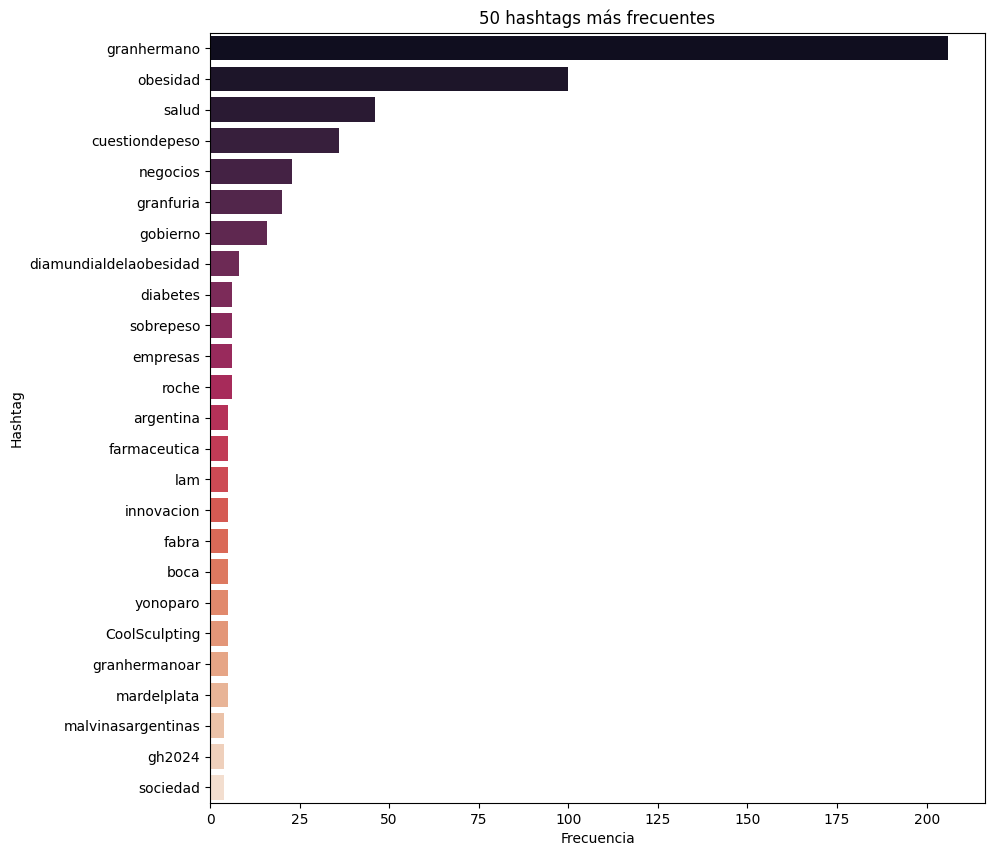

In [ ]:
plt.figure(figsize=(10, 10))
sns.barplot(data=df_hashtags1, y='hashtag', x='frecuencia', palette='rocket',  hue='hashtag')
plt.title('50 hashtags más frecuentes')
plt.xlabel('Frecuencia')
plt.ylabel('Hashtag')
plt.show()

In [ ]:
!pip install circlify

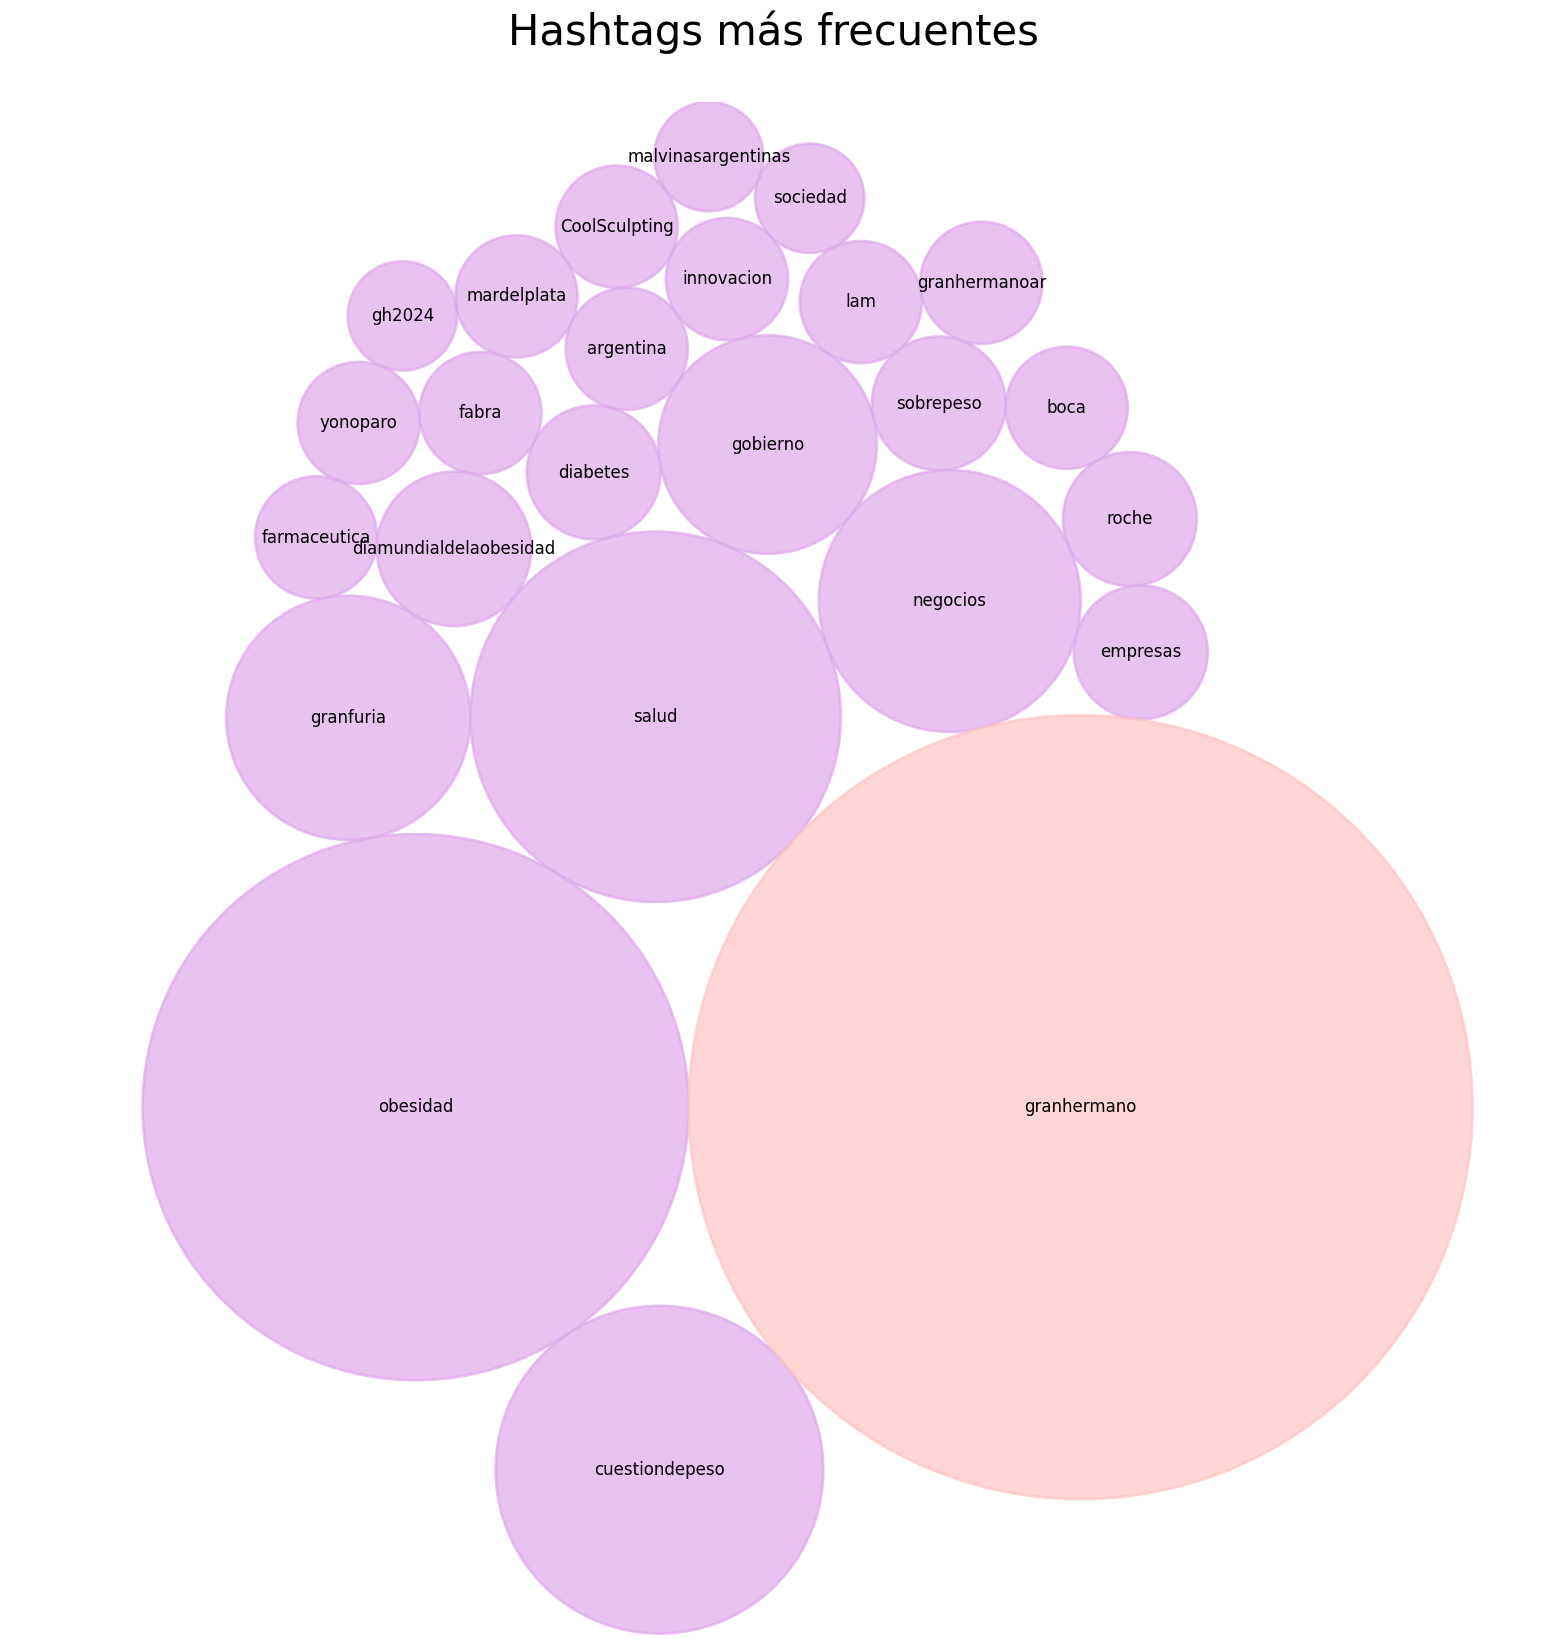

In [ ]:
import circlify
df_hashtags1 = df_hashtags1.sort_values('frecuencia')
circles = circlify.circlify(df_hashtags1['frecuencia'].tolist(),
                            show_enclosure=False,
                            target_enclosure=circlify.Circle(x=0, y=0, r=1))

fig, ax = plt.subplots(figsize=(20, 20))

ax.set_title('Hashtags más frecuentes \n', fontsize= 30)
ax.axis('off')
ax.set_aspect('equal')  # show circles as circles, not as ellipses

lim = max(max(abs(circle.x) + circle.r, abs(circle.y) + circle.r, )
          for circle in circles)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

labels = df_hashtags1['hashtag']
colors = ['#ffc4c4' if val == df_hashtags1['frecuencia'].max() else  "#e0a9ed" for val in df_hashtags1['frecuencia']]
for circle, label, color in zip(circles, labels, colors):
    x, y, r = circle
    ax.add_patch(plt.Circle((x, y), r, alpha=0.7, linewidth=2, color=color))
    ax.annotate(label, (x, y), va='center', ha='center', size=12)
plt.show()

In [ ]:
from wordcloud import WordCloud

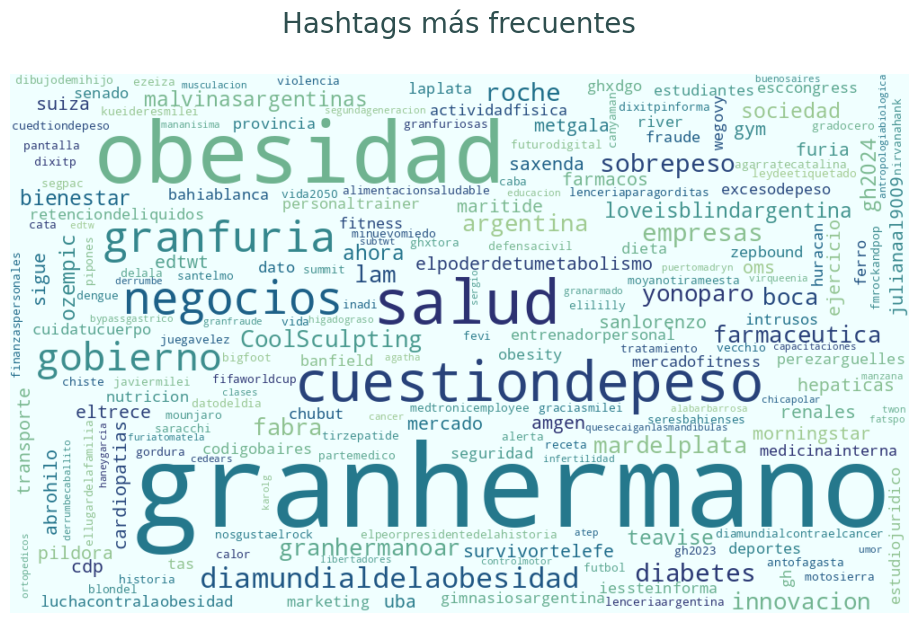

In [ ]:
freq_dict = dict(zip(df_hashtags.sort_values('frecuencia',ascending=False)['hashtag'], df_hashtags.sort_values('frecuencia',ascending=False)['frecuencia']))

wordcloud = WordCloud(width=1000, height=600, background_color='azure', colormap='crest').generate_from_frequencies(freq_dict)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Hashtags más frecuentes\n", fontsize=20, color= 'darkslategray')
plt.show()

### Contenido de tipo texto

#### Ejercicio 5

* a. Identificar las palabras más frecuentes incluyendo stopwords (utilizar gráficos según considere necesario).
* b. Identificar las palabras más frecuentes sin incluir stopwords (utilizar gráficos según considere necesario).
* c. Calcular la cantidad de palabras considerando stopwords por tweet en una nueva variable. Luego otra sin considerar las stopwords. Graficar las distribuciones. Realice una interpretación de los graficos.
* d. Agrupar los tweets por provincia o mes y observar posibles diferencias en los términos más frecuentes entre lugares o períodos.

¿Qué otras variables se les ocurre incluir o generar a partir de los análisis realizados? ¿Qué procesos de curación de datos considera idóneos para implementar en el próximo práctico?


In [ ]:
%%capture
!pip install langid

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import RegexpTokenizer, word_tokenize
import langid

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Nos quedaremos con los tweets en español para poder usar stopwords.

In [ ]:
df['idioma'] = df['rawContent'].apply(lambda x: langid.classify(x)[0]) #Nos quedamos con los tweets en español
df_esp = df[df['idioma'] == 'es'].copy()

In [ ]:
df_esp.shape

(10237, 21)

In [ ]:
import re

tokenizer = RegexpTokenizer(r'\w+')

def tokenize_tweet(tweet):
    #tokens = tokenizer.tokenize(tweet)
    tokens = word_tokenize(tweet, language="spanish")
    lower_cased_tokens = [unidecode(t.lower()) for t in tokens if len(t)>2]
    #lower_cased_tokens= [t.lower() for t in tokens if len(t)>2]
    return lower_cased_tokens


In [ ]:
df_esp['tokens'] = df_esp['rawContent'].apply(tokenize_tweet)

#### Desarrollo punto a

In [ ]:
tokens = [t for tokens in df_esp['tokens'] for t in tokens]

tokens_con_stopwords = pd.Series(tokens).value_counts().reset_index()
tokens_con_stopwords.columns = ['palabras', 'frecuencia']

In [ ]:
tokens_con_stopwords.head(20)

,palabras,frecuencia
0,que,9126
1,con,3360
2,obesidad,2611
3,los,2590
4,una,2396
5,por,2071
6,link_url,1911
7,para,1797
8,obeso,1793
9,sobrepeso,1668


##### 20 Palabras más frecuentes incluyendo stopwords:

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
fig = px.bar(tokens_con_stopwords.head(20), x='frecuencia', y='palabras', orientation='h',
             title='Palabras más frecuentes incluyendo stopwords', color='frecuencia', color_continuous_scale='blugrn')

fig.update_layout(yaxis=dict(autorange='reversed'))
fig.show()

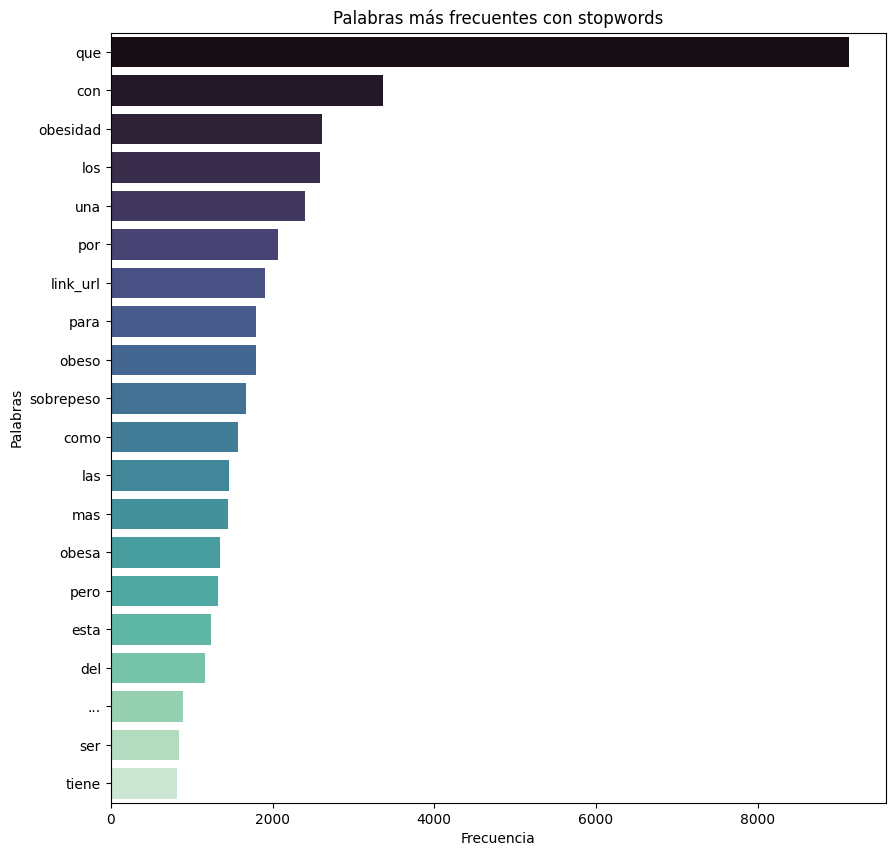

In [ ]:
plt.figure(figsize=(10, 10))
sns.barplot(data=tokens_con_stopwords.head(20), y='palabras', x='frecuencia', palette='mako',  hue='palabras')
plt.title('Palabras más frecuentes con stopwords')
plt.xlabel('Frecuencia')
plt.ylabel('Palabras')
plt.show()

#### Desarrollo punto b

In [ ]:
from nltk.corpus import stopwords

In [ ]:
stop_words = stopwords.words("spanish")
custom_stopwords = {'link_url', '...', 'asi'}
stop_words.extend(custom_stopwords)

In [ ]:
tokens_sin_sw = [t for tokens in df_esp['tokens'] for t in tokens if t not in stop_words]

In [ ]:
tokens_sin_stopwords = pd.Series(tokens_sin_sw).value_counts().reset_index()
tokens_sin_stopwords.columns = ['palabras', 'frecuencia']

#### 20 palabras sin stopwords más frecuentes:

In [ ]:
tokens_sin_stopwords.head(20)

,palabras,frecuencia
0,obesidad,2611
1,obeso,1793
2,sobrepeso,1668
3,mas,1446
4,obesa,1354
5,ser,841
6,gordura,708
7,obesos,571
8,gente,524
9,gordo,516


In [ ]:
fig = px.bar(tokens_sin_stopwords.head(20), x='frecuencia', y='palabras', orientation='h',
             title='Palabras más frecuentes sin stopwords', color='frecuencia', color_continuous_scale='sunset')
fig.update_layout(yaxis=dict(autorange='reversed'))
fig.show()

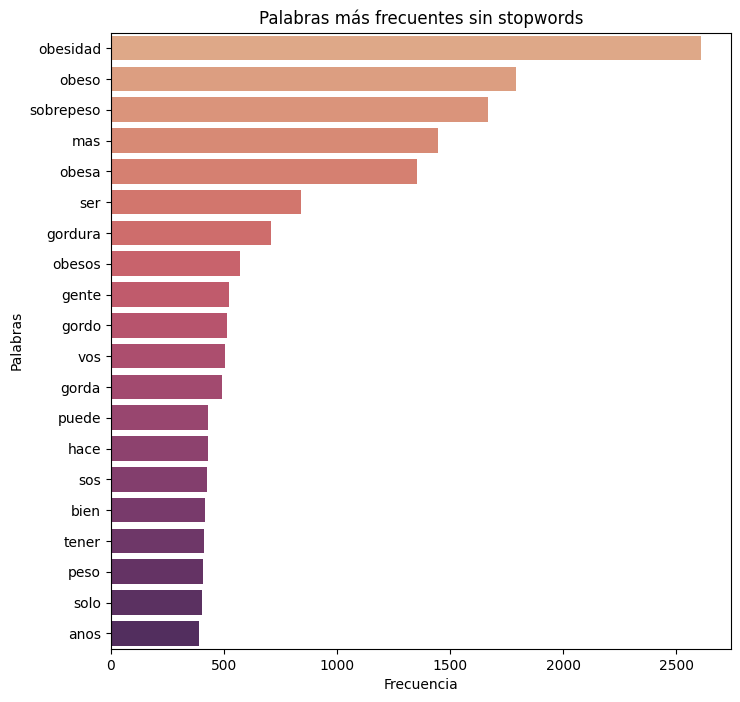

In [ ]:
plt.figure(figsize=(8, 8))
sns.barplot(data=tokens_sin_stopwords.head(20), y='palabras', x='frecuencia', palette='flare',  hue='palabras')
plt.title('Palabras más frecuentes sin stopwords')
plt.xlabel('Frecuencia')
plt.ylabel('Palabras')
plt.show()

#### Desarrollo punto c

In [ ]:
df_esp['num_tokens_con_stopwords'] = df_esp['tokens'].apply(len)
df_esp['num_tokens_con_stopwords'].sort_values(ascending=False).head()

,num_tokens_con_stopwords
4024,248
1987,181
8028,176
7744,176
799,172


In [ ]:
df_esp['num_tokens_sin_stopwords'] = df_esp['tokens'].apply(lambda tokens: len([t for t in tokens if t not in stop_words]))
df_esp['num_tokens_sin_stopwords'].sort_values(ascending=False).head()

,num_tokens_sin_stopwords
4024,193
1987,139
8028,129
7744,125
799,122


Los comentarios más largos son los mismos, pero observamos que tienen más de 50 tokens menos cuando quitamos las stopwords.

Distribución de la cantidad de palabras por tweet considerando y sin considerar stopwords:

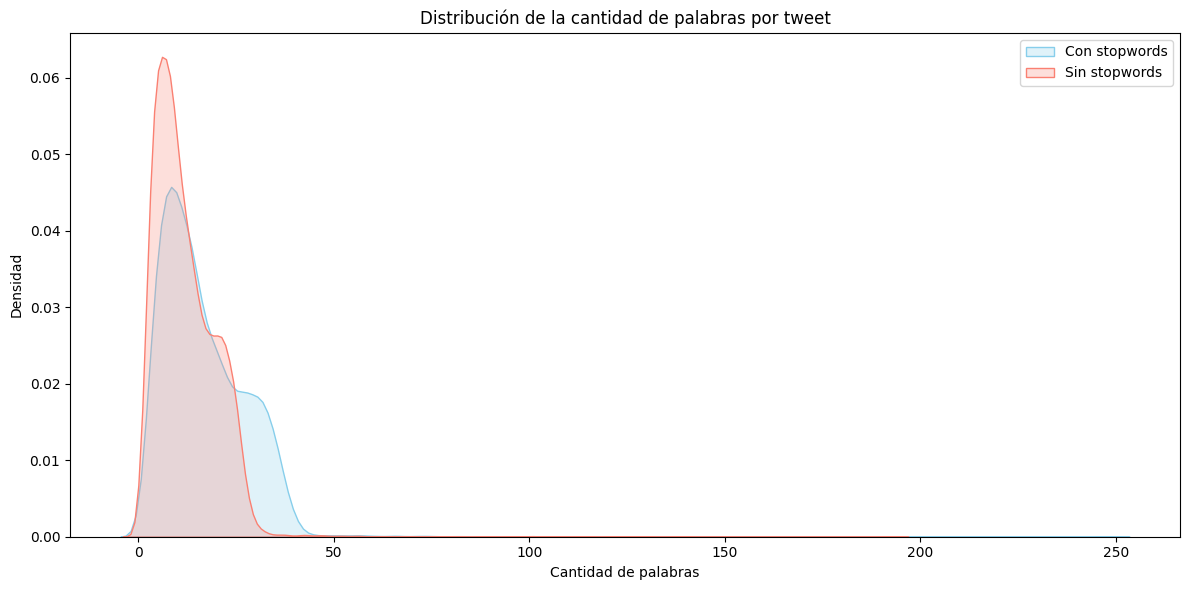

In [ ]:
plt.figure(figsize=(12,6))

sns.kdeplot(df_esp['num_tokens_con_stopwords'], label='Con stopwords', fill=True, color='skyblue')
sns.kdeplot(df_esp['num_tokens_sin_stopwords'], label='Sin stopwords', fill=True, color='salmon')

plt.title('Distribución de la cantidad de palabras por tweet')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

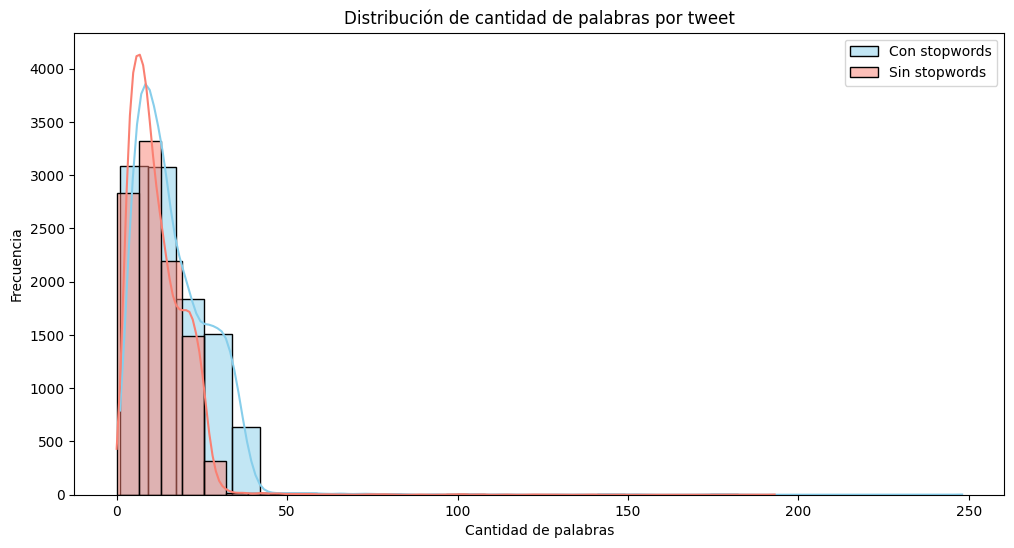

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df_esp['num_tokens_con_stopwords'], color='skyblue', label='Con stopwords', kde=True, bins=30)
sns.histplot(df_esp['num_tokens_sin_stopwords'], color='salmon', label='Sin stopwords', kde=True, bins=30)
plt.title('Distribución de cantidad de palabras por tweet')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [ ]:
df_esp['num_tokens_con_stopwords'].describe()

,num_tokens_con_stopwords
count,"10,237.00"
mean,16.80
std,11.70
min,1.00
25%,8.00
50%,14.00
75%,24.00
max,248.00


In [ ]:
df_esp['num_tokens_sin_stopwords'].describe()

,num_tokens_sin_stopwords
count,"10,237.00"
mean,12.06
std,8.48
min,0.00
25%,6.00
50%,10.00
75%,17.00
max,193.00


Se puede observar que la longitud de los tweets disminuye al eliminar stopwords, pasando de una media de 16 a aproximadamente 12 palabras. Para el caso de tweets con stopwords el 50% tiene 14 palabras o menos, en cambio si no consideramos los stopwords la mediana baja a 10. Esto es esperable ya que muchas palabras, como los artículos, no aportan información semántica.

#### Análisis de sentimiento

##### Pysentimiento

In [ ]:
%%capture
!pip install pysentimiento

In [ ]:
from pysentimiento import create_analyzer
analyzer = create_analyzer(task="sentiment", lang="es")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [ ]:
def sentimiento_tweet(tweet):
    resultado = analyzer.predict(tweet)
    sentimiento = resultado.output
    return sentimiento

In [ ]:
df_esp['pysentimiento'] = df_esp['rawContent'].apply(sentimiento_tweet) # Esta celda tarda alrededor de 3min

Sentimientos detectados en cada tweet usando PySentimiento:

In [ ]:
df_sentimiento = df_esp['pysentimiento'].value_counts().reset_index()
df_sentimiento.columns = ['sentimiento', 'cantidad']
labels = df_sentimiento['sentimiento']
values = df_sentimiento['cantidad']

In [ ]:
colors= px.colors.qualitative.Set3
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3, marker=dict(colors=colors))])
fig.update_layout(
      title='Distribución de sentimientos usando PySentimiento',
      title_font_size=22,
      width=700,
      height=500
)
fig.show()

##### Llama

In [ ]:
!wget -O base_obesidad_sentiment_llama.csv "https://github.com/Eze-Mz/mentoria_2025/raw/main/datasets/base_obesidad_sentiment_llama.csv"
df_llama = pd.read_csv('base_obesidad_sentiment_llama.csv')

--2025-06-30 20:51:09--  https://github.com/Eze-Mz/mentoria_2025/raw/main/datasets/base_obesidad_sentiment_llama.csv
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Eze-Mz/mentoria_2025/main/datasets/base_obesidad_sentiment_llama.csv [following]
--2025-06-30 20:51:10--  https://raw.githubusercontent.com/Eze-Mz/mentoria_2025/main/datasets/base_obesidad_sentiment_llama.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4184021 (4.0M) [text/plain]
Saving to: ‘base_obesidad_sentiment_llama.csv’

base_obesidad_senti 100%[===================>]   3.99M  --.-KB/s    in 0.05s   

2025-06-30 20:51:11 (74

Realizamos también una clasificación de sentimiento utilizando un LLM, llama3.2 8B Instruct. La prompt que utilizamos fue la siguiente:

```
Eres un experto en análisis de sentimientos. Tu tarea es clasificar el sentimiento de comentarios relacionados con obesidad y peso corporal.

Instrucciones:
- Clasifica el sentimiento como: POSITIVO, NEGATIVO, o NEUTRO
- POSITIVO: comentarios que expresan apoyo, comprensión, motivación o actitudes constructivas hacia personas con obesidad
- NEGATIVO: comentarios que expresan discriminación, burla, odio, desprecio o actitudes destructivas hacia personas con obesidad  
- NEUTRO: comentarios informativos, descriptivos o sin carga emocional clara

Responde únicamente con una de estas tres palabras: POSITIVO, NEGATIVO, NEUTRO<|eot_id|><|start_header_id|>user<|end_header_id|>

Comentario a clasificar: "{comment}"
```

In [ ]:
def display_sample(title, content):
    print(f"{title}")
    print("=" * len(title))
    print(content)
    print("\n")

# Filter for negative sentiments and take 10 random samples
negative_samples = df_llama[df_llama['sentiment'] == 'NEGATIVO'].sample(10)

print("10 Random Samples of Negative Tweets:")
print("-----------------------------------")

for i, (index, row) in enumerate(negative_samples.iterrows()):
    display_sample(f"Negative Sample {i+1}", row['rawContent'])

10 Random Samples of Negative Tweets:
-----------------------------------
Negative Sample 1
la del horóscopo me dijo básicamente q deje de comer pq soy una gorda obesa😐


Negative Sample 2
Lo único que se te blanquea es la rosca, de tantas culeadas que te pega tu propio partido, obeso


Negative Sample 3
Lo que más bronca me da es que me puse re triste cuando dijeron que se había muerto x obesidad morbida y que se había dejado morir x likes y fama y mostraba cómo se arruinaba y comía cosas asquerosas.


Negative Sample 4
obesidad morbida link_url


Negative Sample 5
Berlanga y la concja bien puta de tú madre, no podes ir a jugarle a River con 3 jugadores con sobrepeso, 4 pibes de 12 años y 3 reumáticos. Anda a pedir paciencia a la puta que te pario


Negative Sample 6
Será un tipazo, hay que rodearlo de gordura wholesome para que no caiga ante el poder del anillo único.


Negative Sample 7
esto aplica a todo el mundo menos a vos hija de re mil puta a mi sí me traumaste y sólo te deseo 

In [ ]:
# Filter for positive sentiments and take 10 random samples
positive_samples = df_llama[df_llama['sentiment'] == 'POSITIVO'].sample(10)

print("10 Random Samples of Positive Tweets:")
print("-----------------------------------")

for i, (index, row) in enumerate(positive_samples.iterrows()):
    display_sample(f"Positive Sample {i+1}", row['rawContent'])

10 Random Samples of Positive Tweets:
-----------------------------------
Positive Sample 1
Hace un mes y medio empecé la nutri, con todos los miedos, inseguridades y millones de cosas que pasamos las personas son sobrepeso. Hoy tuve control y desde el 13 de mayo a la fecha, bajé 8 kilos🥹❤️‍🩹


Positive Sample 2
hablas de estar gordo como si fuera parte de quien una persona es... la obesidad no es quien sos, quien sos es tu personalidad, la obesidad es grasa acumulada en tu cuerpo por una dieta hipercalórica, nadie "es" gordo, "esta" gordo.


Positive Sample 3
El cambio físico de Jeffrey Jensen que le llevó desde la obesidad hasta ganar un campeonato de culturismo link_url


Positive Sample 4
Tener sobrepeso es una enfermedad y no una ofensa 🤣🤦


Positive Sample 5
no, si superas no cuestionas las decisiones de los demás. enfocate en TU sanación, en TU crecimiento personal y que los demás hagan su vida... es resentimiento sino.


Positive Sample 6
En realidad el sobrepeso no es solo aba

Hicimos por ahora una revisión cualitativa y encontramos casos como:
- "Rapa Nui engorda." -> Casos que podrían ser considerados neutrales clasificados como negativos, que consideramos mal clasificados.
- "Vuelo 28 de enero a BsAs. Problemas en el counter de santiago. Quien hace ni chequeo me da una tarjeta de embarque a otro nombre ,me cobra 4 k sobrepeso y no me da Tíbet de maleta. Mi maleta no llega a Bs As. Nadie se hace cargo. Quien responde x mi perdida???" -> Otros que sí son negativos pero que no se relacionan con la temática, aunque se encontraron pocos de estos casos. Estos también están mal clasificados.
- "Necesito dejar de seguir a la chica del brunch o voy a terminar obesa y pobre" -> Comentarios que si bien no son insultos, sí manifiestan una percepción o postura negativa hacia la gordura.
- "Eso por hacerle caso al obeso estrogenado ese xD" -> La inmensa mayoría son insultos, o comentarios donde la palabra "obeso/a" forma parte de un insulto más largo.

In [ ]:
df_sentimiento_llama = df_llama['sentiment'].value_counts().reset_index()
df_sentimiento_llama.columns = ['sentimiento', 'cantidad']
labels_llama = df_sentimiento_llama['sentimiento']
values_llama = df_sentimiento_llama['cantidad']

In [ ]:
colors= px.colors.qualitative.Set3
fig = go.Figure(data=[go.Pie(labels=labels_llama, values=values_llama, hole=.3, marker=dict(colors=colors))])
fig.update_layout(
      title='Distribución de sentimientos usando Llama',
      title_font_size=22,
      width=700,
      height=500
)
fig.show()

Obtenemos una distribución de sentimiento similar a la observada con pysentimiento. En esta clasificación el porcentaje de positivos es aún menor. Deberíamos realizar algunas pruebas más, pero ambas clasificaciones, con una distribución similar, nos parecen un buen indicio de que la gran mayoría de la conversación sobre la obesidad y el sobrepeso en twitter es negativa.

#### Keyphrases

In [ ]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

df_esp['tokens_sin_stopwords'] = df_esp['tokens'].apply(lambda tokens: [t for t in tokens if t not in stop_words])

# juntar los tokens de todos los comentarios
tokens_lists = df_esp['tokens_sin_stopwords'].to_list()
all_tokens = [token for sublist in tokens_lists for token in sublist]
print(f"Cantidad de documentos: {len(tokens_lists)}")
print(f"Cantidad de tokens: {len(all_tokens)}")


# crear y filtrar bigramas por frecuencia
bigram_measures = BigramAssocMeasures()
finder_bi = BigramCollocationFinder.from_words(all_tokens, window_size=3) #probar con diferentes windows_size
finder_bi.apply_freq_filter(15) #otro parámetro para modificar, afecta sobre todo al pmi

# calcular scores a partir de la frecuencia, pmi, y llr, crear un df con los resultados
pmi_scored = finder_bi.score_ngrams(bigram_measures.pmi)
llr_scored = finder_bi.score_ngrams(bigram_measures.likelihood_ratio)
freq_dist = dict(finder_bi.ngram_fd.items())
df_pmi = pd.DataFrame(pmi_scored, columns=["bigram", "pmi_score"])
df_llr = pd.DataFrame(llr_scored, columns=["bigram", "llr_score"])
df_freq = pd.DataFrame(freq_dist.items(), columns=["bigram", "count"])

bigrams_df = df_pmi.merge(df_llr, on="bigram").merge(df_freq, on="bigram")
bigrams_df = bigrams_df.sort_values(by="pmi_score", ascending=False).reset_index(drop=True)

# poner un "_" entre las palabras
bigrams_df["bigram_str"] = bigrams_df["bigram"].apply(lambda x: f"{x[0]}_{x[1]}")
print(f"Cantidad de bigramas: {len(bigrams_df)}")

Cantidad de documentos: 10237
Cantidad de tokens: 123469
Cantidad de bigramas: 262


In [ ]:
bigrams_df.sort_values(by="pmi_score", ascending=False).head(10)

,bigram,pmi_score,llr_score,count,bigram_str
0,"(higado, graso)",11.40,110.69,15,higado_graso
1,"(edision, lamentable)",11.26,146.76,20,edision_lamentable
2,"(sinceramente, edision)",11.09,143.77,20,sinceramente_edision
3,"(permite, agresion)",11.08,143.46,20,permite_agresion
4,"(lamentable, permite)",10.95,141.18,20,lamentable_permite
5,"(malvinas, argentinas)",10.95,112.05,16,malvinas_argentinas
6,"(sinceramente, lamentable)",10.90,140.23,20,sinceramente_lamentable
7,"(resistencia, insulina)",10.63,107.63,16,resistencia_insulina
8,"(pediatra, sabiendo)",10.53,175.79,26,pediatra_sabiendo
9,"(buenos, aires)",10.51,140.79,21,buenos_aires


In [ ]:
bigrams_df.sort_values(by="count", ascending=False).head(10)

,bigram,pmi_score,llr_score,count,bigram_str
96,"(obesidad, morbida)",4.30,604.18,265,obesidad_morbida
111,"(obesidad, enfermedad)",3.66,267.05,152,obesidad_enfermedad
123,"(gordo, obeso)",3.24,202.90,142,gordo_obeso
112,"(gorda, obesa)",3.66,232.99,137,gorda_obesa
95,"(puede, ser)",4.40,270.26,123,puede_ser
160,"(ser, obeso)",2.10,75.47,105,ser_obeso
218,"(sobrepeso, obesidad)",0.52,6.02,101,sobrepeso_obesidad
82,"(obeso, morbido)",5.00,227.72,82,obeso_morbido
125,"(obesidad, diabetes)",3.17,104.70,75,obesidad_diabetes
149,"(sos, obeso)",2.42,59.16,66,sos_obeso


In [ ]:
bigrams_df.sort_values(by="llr_score", ascending=False).head(10)

,bigram,pmi_score,llr_score,count,bigram_str
96,"(obesidad, morbida)",4.30,604.18,265,obesidad_morbida
95,"(puede, ser)",4.40,270.26,123,puede_ser
111,"(obesidad, enfermedad)",3.66,267.05,152,obesidad_enfermedad
112,"(gorda, obesa)",3.66,232.99,137,gorda_obesa
82,"(obeso, morbido)",5.00,227.72,82,obeso_morbido
47,"(hijo, puta)",7.32,209.36,49,hijo_puta
54,"(dia, mundial)",6.86,206.34,52,dia_mundial
123,"(gordo, obeso)",3.24,202.90,142,gordo_obeso
64,"(gordura, hinchazon)",6.32,202.55,55,gordura_hinchazon
67,"(bajar, peso)",6.18,197.44,57,bajar_peso


Creemos que hay mucho para explorar a partir de las keypharses detectadas. En principio reflejan un poco nuestra intuición a partir de la lectura de algunos comentarios y de la distribución de sentimientos encontrada, muchos de los bigramas más frecuentes tienen una fuerte carga negativa: "obesidad_morbida", "gordo_obeso". Observamos también algunos insultos.

Por medio de la medida pmi encontramos otros interesantes como "higado_graso", "resistencia_insulina", "permite_agresion". Los bigramas encontrados con esta métrica varían mucho modificando el filtro por frecuencia de tokens, nos queda averiguar cómo definir algún criterio para determinar a partir de qué frecuencia filtrar.

### Análisis estadístico

#### Ejercicio 6

Se comenzará el plan de análisis que será desarrollado a lo largo de los tres prácticos. En esta primera parte más introductoria les propongo:

* a. Reconocer posibles correlaciones entre variables. ¿En qué supuesto se basan?. Luego de aplicar el test estadístico interpretar los resultados y fundamentar la elección del mismo a partir de la naturaleza de los datos. No duden en consultarme ante cualquier inconveniente en este punto!

In [ ]:
df_esp.columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'hora', 'dia', 'semana', 'nombre_mes',
       'pcia1', 'provincia', 'hashtags1', 'idioma', 'tokens',
       'num_tokens_con_stopwords', 'num_tokens_sin_stopwords', 'pysentimiento',
       'tokens_sin_stopwords'],
      dtype='object')

In [ ]:
columnas = ['id_str','replyCount', 'retweetCount', 'likeCount', 'quoteCount', 'viewCount',
             'mes', 'user_id', 'tokens','num_tokens_con_stopwords', 'num_tokens_sin_stopwords']

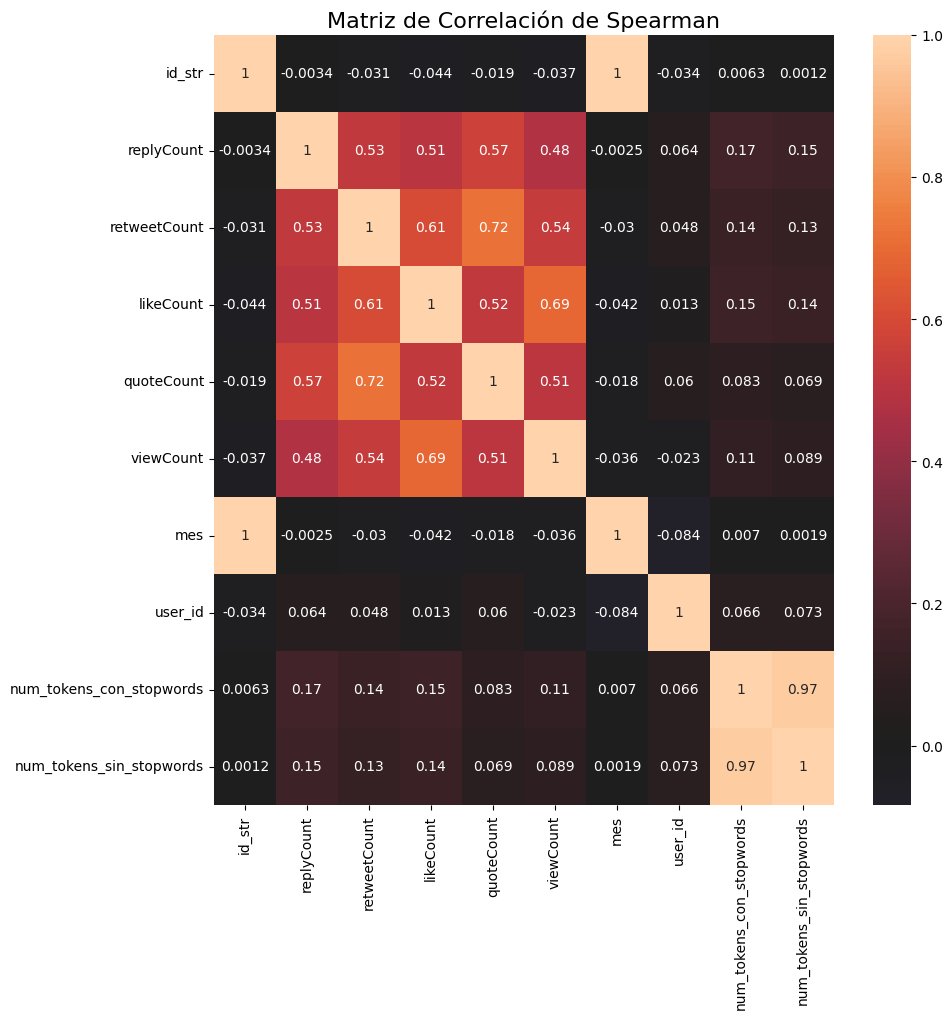

In [ ]:
fig = plt.figure(figsize=(10,10));
sns.heatmap(df_esp[columnas].select_dtypes(include='number').corr(method='spearman'), annot=True, center=0)
plt.title('Matriz de Correlación de Spearman', fontsize=16)
plt.show()

Usamos Spearman porque no exige normalidad, es robusto a outliers. Como hemos visto que las distribuciones de nuestros datos, en su mayoría, son fuertermente sesgadas, consideramos que es más adecuada la correlación de Spearman. Igualmente en los test más abajo calcularemos la de pearson para ver si hay mucha diferencia.

Observamos correlaciones altas entre las variables likeCount, retweetCount, quoteCounte, viewCount, replyCount que son de interacción. Esto se debe a que los tweets más populares suelen recibir más interacciones en general. Este comportamiento es totalmente normal en Twitter, donde los tweets que alcanzan mayor visibilidad suelen recibir distintos tipos de interacción al mismo tiempo, más likes, retweets, respuestas, visualizaciones y citas. Sin embargo, el tamaño del mensaje no siempre influye en su viralización. Muchas veces son los tweets cortos, directos o con cierto impacto emocional los que logran una mayor difusión o tendencia. Esto sugiere que no es tanto la cantidad de palabras lo que genera interacción, sino el contenido y el momento en el que se publica.

In [ ]:
from scipy.stats import pearsonr, spearmanr

def analizar_correlacion(df, col1, col2):
  """
  Calcula y imprime la correlación de Pearson y Spearman entre dos columnas de un DataFrame.

  Args:
    df (pd.DataFrame): El DataFrame que contiene las columnas.
    col1 (str): El nombre de la primera columna.
    col2 (str): El nombre de la segunda columna.
  """
  # Eliminar filas donde cualquiera de las dos columnas tenga NaN
  df_cleaned = df.dropna(subset=[col1, col2])

  # Verificar si hay suficientes datos o varianza
  if df_cleaned.shape[0] < 2 or df_cleaned[col1].nunique() < 2 or df_cleaned[col2].nunique() < 2:
    print(f"No hay suficientes datos o varianza para correlacionar '{col1}' y '{col2}'.")
    return

  x = df_cleaned[col1]
  y = df_cleaned[col2]

  print(f"Analizando correlación entre '{col1}' y '{col2}' (usando {len(x)} pares de datos):")

  # Pearson
  r_p, p_p = pearsonr(x, y)
  print(f"Pearson r = {r_p:.3f}, p-value = {p_p:.3e}")

  # Spearman
  r_s, p_s = spearmanr(x, y)
  print(f"Spearman ρ = {r_s:.3f}, p-value = {p_s:.3e}")

  if p_s < 0.05:
    print("El p-value de Spearman sugiere una correlación monotónica significativa.")
  else:
    print("El p-value de Spearman no sugiere una correlación monotónica significativa.")

analizar_correlacion(df_esp, 'likeCount', 'viewCount')

Analizando correlación entre 'likeCount' y 'viewCount' (usando 10182 pares de datos):
Pearson r = 0.572, p-value = 0.000e+00
Spearman ρ = 0.692, p-value = 0.000e+00
El p-value de Spearman sugiere una correlación monotónica significativa.


In [ ]:
analizar_correlacion(df_esp, 'likeCount', 'quoteCount')

Analizando correlación entre 'likeCount' y 'quoteCount' (usando 10237 pares de datos):
Pearson r = 0.447, p-value = 0.000e+00
Spearman ρ = 0.522, p-value = 0.000e+00
El p-value de Spearman sugiere una correlación monotónica significativa.


In [ ]:
analizar_correlacion(df_esp, 'likeCount', 'replyCount')

Analizando correlación entre 'likeCount' y 'replyCount' (usando 10237 pares de datos):
Pearson r = 0.366, p-value = 3.458e-322
Spearman ρ = 0.509, p-value = 0.000e+00
El p-value de Spearman sugiere una correlación monotónica significativa.


In [ ]:
analizar_correlacion(df_esp, 'likeCount', 'retweetCount')

Analizando correlación entre 'likeCount' y 'retweetCount' (usando 10237 pares de datos):
Pearson r = 0.715, p-value = 0.000e+00
Spearman ρ = 0.606, p-value = 0.000e+00
El p-value de Spearman sugiere una correlación monotónica significativa.


Lo primero que debemos puntualizar es que con un tamaño muestral ($n$) muy grande, incluso una correlación extremadamente débil y sin importancia práctica (por ejemplo, $r=0.08$) puede resultar "estadísticamente significativa". Recordemos que el valor p responde a la pregunta: *¿Es probable que esta relación exista realmente en la población o es solo fruto del azar en mi muestra?* Con una muestra tan grande, el test tiene un poder altísimo para detectar cualquier cosa que no sea exactamente cero. Por poner un ejemplo, mostramos a continuación la correlación entre `replyCount` y `user_id` ($-0.03$ con la correlación de Pearson):

In [ ]:
analizar_correlacion(df_esp, 'replyCount', 'user_id')

Analizando correlación entre 'replyCount' y 'user_id' (usando 10237 pares de datos):
Pearson r = 0.030, p-value = 2.556e-03
Spearman ρ = 0.064, p-value = 9.120e-11
El p-value de Spearman sugiere una correlación monotónica significativa.


Lo más importante es entonces interpretar el valor de la correlación estimada. Como ya hemos mencionado las métricas de interacción aparecen correlacionadas porque los tweets virales tienden a tener indistintamente interacciones de distinto tipo.

Obviamente las variables que hemos creado a partir de los tokens (`num_tokens_`) están correlacionadas. Y, por último, observamos una muy leve correlación positiva (mayor a $0.10$ y menor a $0.20$ en todos los casos excepto `quoteCount`) entre las métricas de interacción y la cantidad de tokens (con y sin stopwords). Recordemos que estamos utilizando la correlación de Spearman, con la correlación de Pearson estos valores mencionados al final son muchos menores.

### Ejercicio final

* ¿Qué hallazgos te parecieron más interesantes?
* ¿Qué hipótesis o líneas de análisis podrías plantear a partir de lo visto?
* A partir del ejercicio 5. ¿Qué otras variables o aspectos sería útil incorporar en el análisis?


La fecha de entrega del práctico es para el día 30/6, la semana del 16/6 tendremos una instancia de consulta con cada grupo para ver como vienen con el práctico. El entregable será una notebook, vayan realizando visualizaciones pensando en la presentación de video posterior al segundo práctico.
Recuerden que es una instancia de aprendizaje por lo cual no duden en consultar lo que necesiten para resolver el práctico.  

Les dejo disponibles algunos recursos de introducción al NLP y text mining que podrían ser de utilidad.

NLP avanzado con spacy: https://course.spacy.io/es/

Algunos hallazgos que nos parecieron interesantes son:
- El 25% de los usuarios tiene 5 o más tweets publicados.
- Encontramos que muchos tweets no son pertinentes y podrían considerarse ruidos, por lo que nos interesaría analizar y entender mejor cómo se construyo la base de datos.
- En esta primera exploración hemos visto que el discurso de odio esta presente de manera recurrente en muchos comentarios y nos gustaría entender mejor que ideas se expresan en estos posteos.
- Encontramos que, al parecer, más del 80% de los posteos son negativos.

Más que hipótesis se nos ocurren líneas de análisis o tipos de análisis que podríamos realizar. Nos interesaría profundizar la percepción social de la temática y como se construye esa percepción en los distintos tópicos alrededor de los cuales giran los discursos sobre la obesidad. En un sentido general, hemos observado que la conversación se da en torno a por ejemplo ciertos programas televisivos como cuestión de peso o gran hermano, otros tienen que ver con el deporte, la salud es un tema que aparece de manera frecuente, así como también se observan muchos comentarios que son autorreflexivos por parte de su autor. Nos preguntamos cuáles son las ideas centrales que se manifiestan en la conversación en Twitter acerca de la obsedidad? En particular lo subyacente a los discursos, los conceptos y asociaciones que sustentan las ideas expresadas en los comentarios.

Para ello pensamos que sería interesante trabajar con algún algoritmo de clustering para encontrar tópicos y también construir un knowledge graph a partir de estos datos con el objetivo de intentar descubrir esas asociaciones subyacentes a los discursos.

Pensamos que algunas variables que sería interesante incorporar (dependiendo de lo que finalmente vayamos a hacer) son:
- el sentimiento de los comentarios
- variable que indique hatespeech o insultos
- una que defina la temática, como resultado de aplicar un algoritmo de clustering

Por último consideramos fundamental incorporar:
- limpieza de comentarios irrelevantes
- limpieza de palabras como 'link_url'

